In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/co2.csv


<p style="background-color:#3D8D7A;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:10px 20px;"><b>Lineer Regression Project 1(CO2 Emissions)</b></p>

<b>Follow me </b>[Linkedin](https://www.linkedin.com/in/ejeshbozjanova/) | [Github](github.com/ejeshbozjanova) | [Kaggle](www.kaggle.com/ejeshbozjanova) | [Medium](https://medium.com/@ejeshbozjanova)  |

**About Dataset**
- This dataset contains information about various vehicles' carbon dioxide (CO2) emissions and fuel consumption. 
- In the context of Machine Learning (ML), this dataset is often used to predict CO2 emissions based on vehicle characteristics or to analyze fuel efficiency of vehicles. 
- The goal could be to predict CO2 emissions or fuel consumption based on the features of the vehicles.
- There are total 7385 rows and 12 columns. 

**The columns in the dataset can be described as follows:**

1. **Make**: The brand of the vehicle.
2. **Model**: The model of the vehicle.
3. **Vehicle Class**: The class of the vehicle (e.g., compact, SUV).
4. **Engine Size(L)**: The engine size in liters.
5. **Cylinders**: The number of cylinders in the engine.
6. **Transmission**: The type of transmission (e.g., automatic, manual).
7. **Fuel Type**: The type of fuel used (e.g., gasoline, diesel).
8. **Fuel Consumption City (L/100 km)**: Fuel consumption in the city (liters per 100 kilometers).
9. **Fuel Consumption Hwy (L/100 km)**: Highway (out-of-city) fuel consumption.
10. **Fuel Consumption Comb (L/100 km)**: Combined (city and highway) fuel consumption.
11. **Fuel Consumption Comb (mpg)**: Combined fuel consumption in miles per gallon.
12. **CO2 Emissions(g/km)**: CO2 emissions in grams per kilometer.

**Model**

**The "Model" column includes terms that identify specific features or configurations of vehicles:**
- `4WD/4X4`: Four-wheel drive. A drive system where all four wheels receive power.
- `AWD`: All-wheel drive. Similar to 4WD but often with more complex mechanisms for power distribution.
- `FFV`: Flexible-fuel vehicle. Vehicles that can use multiple types of fuel, such as both gasoline and ethanol blends.
- `SWB`: Short wheelbase.
- `LWB`: Long wheelbase.
- `EWB`: Extended wheelbase.

**Transmission**

**The "Transmission" column indicates the type of transmission system in the vehicle:**
- `A`: Automatic. A transmission type that operates without the need for the driver to manually change gears.
- `AM`: Automated manual. A version of a manual transmission that is automated.
- `AS`: Automatic with select shift. An automatic transmission that allows for manual intervention.
- `AV`: Continuously variable. A transmission that uses continuously varying ratios instead of fixed gear ratios.
- `M`: Manual. A transmission type that requires the driver to manually change gears.
- `3 - 10`: Number of gears in the transmission.

**Fuel Type**

**The "Fuel Type" column specifies the type of fuel used by the vehicle:**
- `X`: Regular gasoline.
- `Z`: Premium gasoline.
- `D`: Diesel.
- `E`: Ethanol (E85).
- `N`: Natural gas.

**Vehicle Class**

**The "Vehicle Class" column categorizes vehicles by size and type:**
- `COMPACT`: Smaller-sized vehicles.
- `SUV - SMALL`: Smaller-sized sports utility vehicles.
- `MID-SIZE`: Medium-sized vehicles.
- `TWO-SEATER`: Vehicles with two seats.
- `MINICOMPACT`: Very small-sized vehicles.
- `SUBCOMPACT`: Smaller than compact-sized vehicles.
- `FULL-SIZE`: Larger-sized vehicles.
- `STATION WAGON - SMALL`: Smaller-sized station wagons.
- `SUV - STANDARD`: Standard-sized sports utility vehicles.
- `VAN - CARGO`: Vans designed for cargo.
- `VAN - PASSENGER`: Vans designed for passenger transportation.
- `PICKUP TRUCK - STANDARD`: Standard-sized pickup trucks.
- `MINIVAN`: Smaller-sized vans.
- `SPECIAL PURPOSE VEHICLE`: Vehicles designed for special purposes.
- `STATION WAGON - MID-SIZE`: Mid-sized station wagons.
- `PICKUP TRUCK - SMALL`: Smaller-sized pickup trucks.

This dataset can be used to understand the fuel efficiency and environmental impact of vehicles. Machine learning models can use these features to predict CO2 emissions or perform analyses comparing the fuel consumption of different vehicles.

In [2]:
!pip install plotly


In [3]:
#!pip install --upgrade pip

In [4]:
!pip install yellowbrick



# <font color='#3D8D7A'> <b>EDA and Data Cleaning</b><font color='black'>

## <font color=#3D8D7A> <b>Import Library</b><font color='black'>

In [5]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns


import plotly.express as px
import scipy.stats as stats

%matplotlib inline  

from scipy import stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import ElasticNet, ElasticNetCV

from sklearn.model_selection import cross_val_score, cross_validate

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from yellowbrick.regressor import ResidualsPlot, PredictionError

import warnings
warnings.filterwarnings("ignore")

In [6]:
#co2 = pd.read_csv('co2.csv')
#df = co2.copy()

In [7]:
co2 = pd.read_csv('/kaggle/input/co2.csv')
df = co2.copy()

## <font color='#3D8D7A'> <b>Read Dataset</b><font color='black'>

In [8]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [9]:
df.sample(5)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
965,SUBARU,OUTBACK AWD,SUV - SMALL,3.6,6,AS5,X,13.4,9.7,11.7,24,269
571,JEEP,CHEROKEE 4X4,SUV - SMALL,2.4,4,A9,X,11.3,8.3,10.0,28,230
3496,CHEVROLET,COLORADO,PICKUP TRUCK - SMALL,2.5,4,M6,X,12.2,9.2,10.9,26,254
5958,INFINITI,Q60 AWD,SUBCOMPACT,3.0,6,AS7,Z,12.3,8.7,10.7,26,251
2257,AUDI,S8 QUATTRO,MID-SIZE,4.0,8,AS8,Z,15.7,9.4,12.8,22,300


In [10]:
df.tail()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7384,VOLVO,XC90 T6 AWD,SUV - STANDARD,2.0,4,AS8,Z,12.2,8.7,10.7,26,248


In [11]:
df.shape

(7385, 12)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [13]:
df.rename(columns={ 'Make': 'make',
                    'Model': 'model',
                    'Vehicle Class': 'vehicle_class',
                    'Engine Size(L)': 'engine_size',
                    'Cylinders': 'cylinders',
                    'Transmission': 'transmission',
                    'Fuel Type': 'fuel_type',
                    'Fuel Consumption City (L/100 km)': 'fuel_cons_city',
                    'Fuel Consumption Hwy (L/100 km)': 'fuel_cons_hwy',
                    'Fuel Consumption Comb (L/100 km)': 'fuel_cons_comb',
                    'Fuel Consumption Comb (mpg)': 'fuel_cons_comb_mpg',
                    'CO2 Emissions(g/km)': 'co2'
                    }, inplace=True)

In [14]:
df.columns 

Index(['make', 'model', 'vehicle_class', 'engine_size', 'cylinders',
       'transmission', 'fuel_type', 'fuel_cons_city', 'fuel_cons_hwy',
       'fuel_cons_comb', 'fuel_cons_comb_mpg', 'co2'],
      dtype='object')

In [15]:
# Check out the missing values

missing_count = df.isnull().sum()
value_count = df.isnull().count()
missing_percentage = round(missing_count / value_count * 100, 2)
missing_df = pd.DataFrame({"count": missing_count, "percentage": missing_percentage})
missing_df

,count,percentage
make,0,0.0
model,0,0.0
vehicle_class,0,0.0
engine_size,0,0.0
cylinders,0,0.0
transmission,0,0.0
fuel_type,0,0.0
fuel_cons_city,0,0.0
fuel_cons_hwy,0,0.0
fuel_cons_comb,0,0.0


In [16]:
df.duplicated().sum()

1103

In [17]:
duplicated_rows = df[df.duplicated(keep=False)]

duplicated_rows

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb,fuel_cons_comb_mpg,co2
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
12,ALFA ROMEO,4C,TWO-SEATER,1.8,4,AM6,Z,9.7,6.9,8.4,34,193
13,ASTON MARTIN,DB9,MINICOMPACT,5.9,12,A6,Z,18.0,12.6,15.6,18,359
15,ASTON MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,Z,17.4,11.3,14.7,19,338
...,...,...,...,...,...,...,...,...,...,...,...,...
7356,TOYOTA,Tundra,PICKUP TRUCK - STANDARD,5.7,8,AS6,X,17.7,13.6,15.9,18,371
7365,VOLKSWAGEN,Golf GTI,COMPACT,2.0,4,M6,X,9.8,7.3,8.7,32,203
7366,VOLKSWAGEN,Jetta,COMPACT,1.4,4,AS8,X,7.8,5.9,7.0,40,162
7367,VOLKSWAGEN,Jetta,COMPACT,1.4,4,M6,X,7.9,5.9,7.0,40,163


**Some duplicate rows are completely identical, while others have slight variations. Possible reasons for these duplicates include:**

**Data Entry Errors** – The same data may have been recorded multiple times.

**Different Time Periods** – Performance metrics for the same model may have been collected over different years.

**Model Variations** – Different versions or updates of the same model may be present.

Understanding the context and how the data was collected is essential in determining the cause of duplicates. Whether to remove them depends on the analysis goal:

* If unique observations are needed, duplicates can be removed.
* If tracking changes over time or analyzing variations, keeping them may be beneficial.
  
However, since I will be using a linear model, I do not plan to remove these rows. Duplicate entries contain similar values, which do not significantly impact the model’s predictions. Linear regression focuses on capturing overall trends, so retaining duplicates should not distort the results

In [18]:
# Let's observe unique values 

def get_unique_values(df):
    
    output_data = []

    for col in df.columns:

        # If the number of unique values in the column is less than or equal to 5
        if df.loc[:, col].nunique() <= 10:
            # Get the unique values in the column
            unique_values = df.loc[:, col].unique()
            # Append the column name, number of unique values, unique values, and data type to the output data
            output_data.append([col, df.loc[:, col].nunique(), unique_values, df.loc[:, col].dtype])
        else:
            # Otherwise, append only the column name, number of unique values, and data type to the output data
            output_data.append([col, df.loc[:, col].nunique(),"-", df.loc[:, col].dtype])

    output_df = pd.DataFrame(output_data, columns=['Column Name', 'Number of Unique Values', ' Unique Values ', 'Data Type'])

    return output_df

In [19]:
get_unique_values(df)

,Column Name,Number of Unique Values,Unique Values,Data Type
0,make,42,-,object
1,model,2053,-,object
2,vehicle_class,16,-,object
3,engine_size,51,-,float64
4,cylinders,8,"[4, 6, 12, 8, 10, 3, 5, 16]",int64
5,transmission,27,-,object
6,fuel_type,5,"[Z, D, X, E, N]",object
7,fuel_cons_city,211,-,float64
8,fuel_cons_hwy,143,-,float64
9,fuel_cons_comb,181,-,float64


In [20]:
# Basic statistics summary of Numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_size,7385.0,3.160068,1.354170,0.9,2.0,3.0,3.7,8.4
cylinders,7385.0,5.615030,1.828307,3.0,4.0,6.0,6.0,16.0
fuel_cons_city,7385.0,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
fuel_cons_hwy,7385.0,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
fuel_cons_comb,7385.0,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1
fuel_cons_comb_mpg,7385.0,27.481652,7.231879,11.0,22.0,27.0,32.0,69.0
co2,7385.0,250.584699,58.512679,96.0,208.0,246.0,288.0,522.0


In [21]:
# Basic statistics summary of Object features

df.describe(include= 'object').T

,count,unique,top,freq
make,7385,42,FORD,628
model,7385,2053,F-150 FFV 4X4,32
vehicle_class,7385,16,SUV - SMALL,1217
transmission,7385,27,AS6,1324
fuel_type,7385,5,X,3637


# <font color='#3D8D7A'> <b>Data Visualisation</b><font color='black'>


In [22]:
import matplotlib.pyplot as plt
import matplotlib

In [23]:
# Let's specify a usable font
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

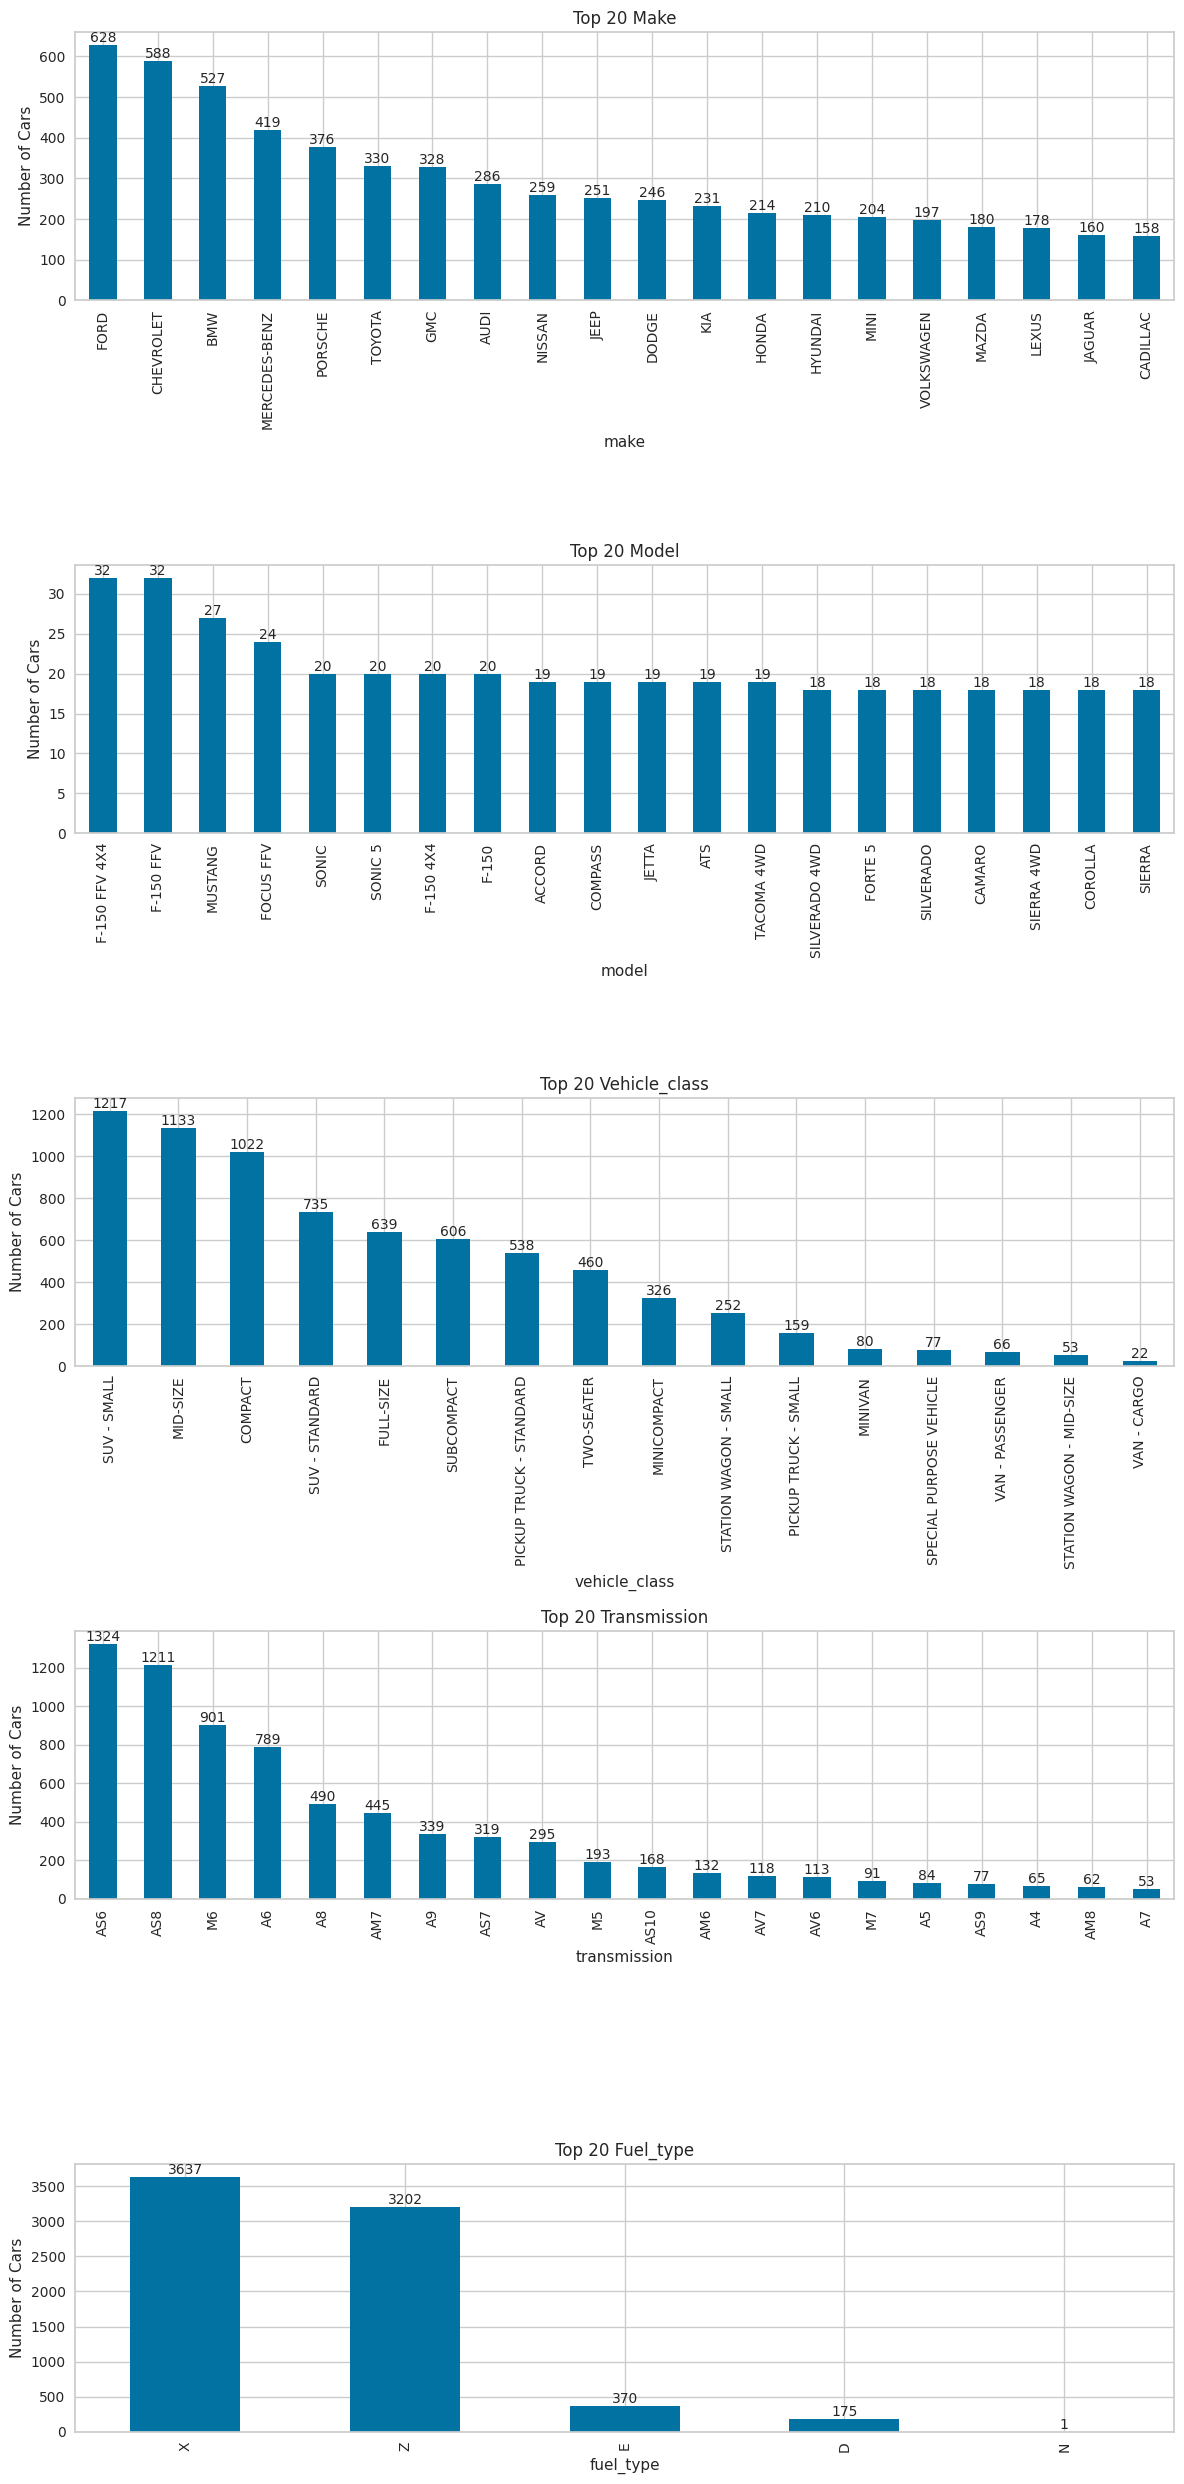

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Define categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Drawing bar graphs
fig, axes = plt.subplots(nrows=len(categorical_columns), ncols=1, figsize=(12, 5 * len(categorical_columns)))

for i, col in enumerate(categorical_columns):
    counts = df[col].value_counts().sort_values(ascending=False).head(20)
    ax = axes[i] if len(categorical_columns) > 1 else axes
    counts.plot(kind="bar", ax=ax)
    ax.set_title(f'Top 20 {col.capitalize()}')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of Cars')
    ax.set_xticklabels(counts.index, rotation=90)
    ax.bar_label(ax.containers[0], labels=counts.values, fontsize=10)

plt.tight_layout()
plt.show()


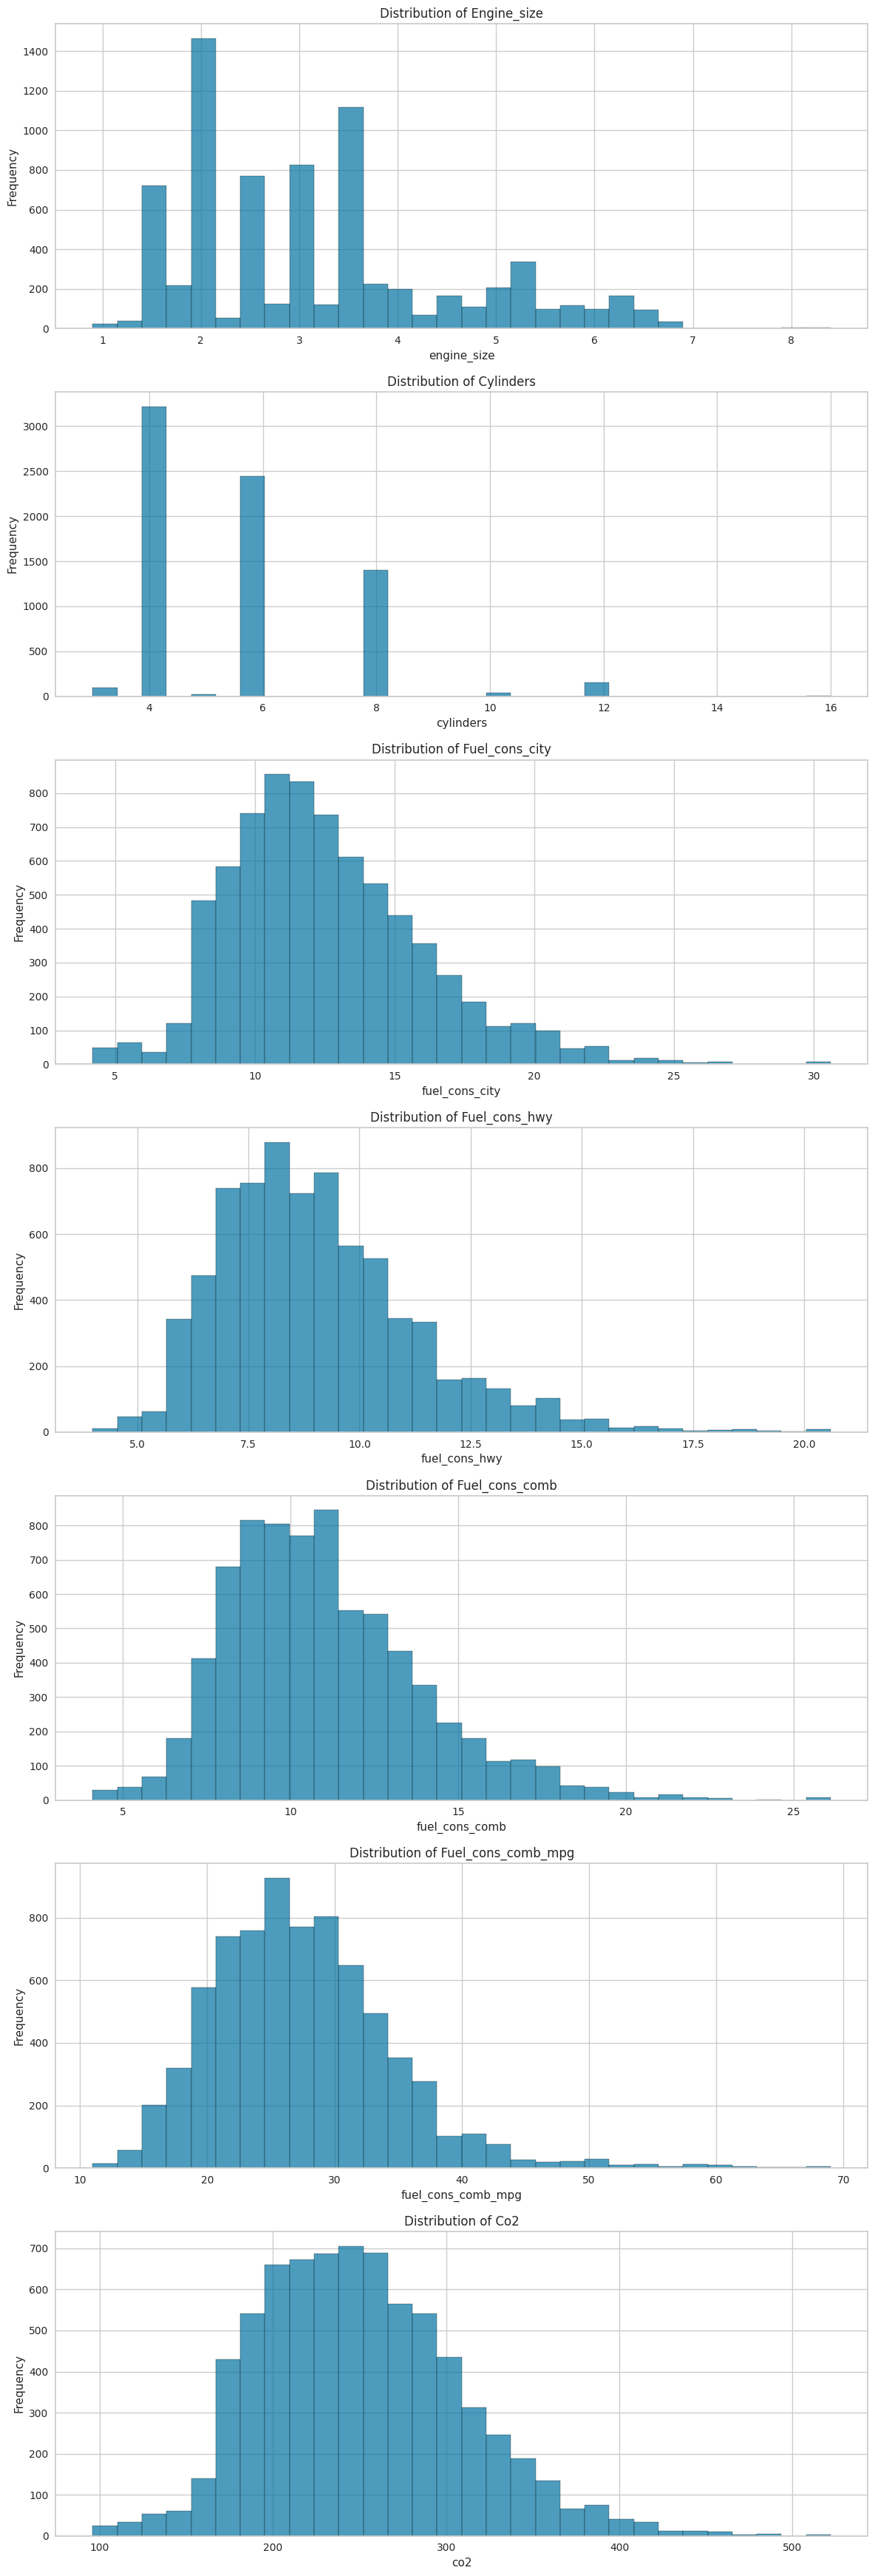

In [25]:
# Determine numeric columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Drawing histogram graphs for numerical columns
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=1, figsize=(12, 5 * len(numerical_columns)))

for i, col in enumerate(numerical_columns):
    ax = axes[i] if len(numerical_columns) > 1 else axes
    df[col].plot(kind="hist", bins=30, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col.capitalize()}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

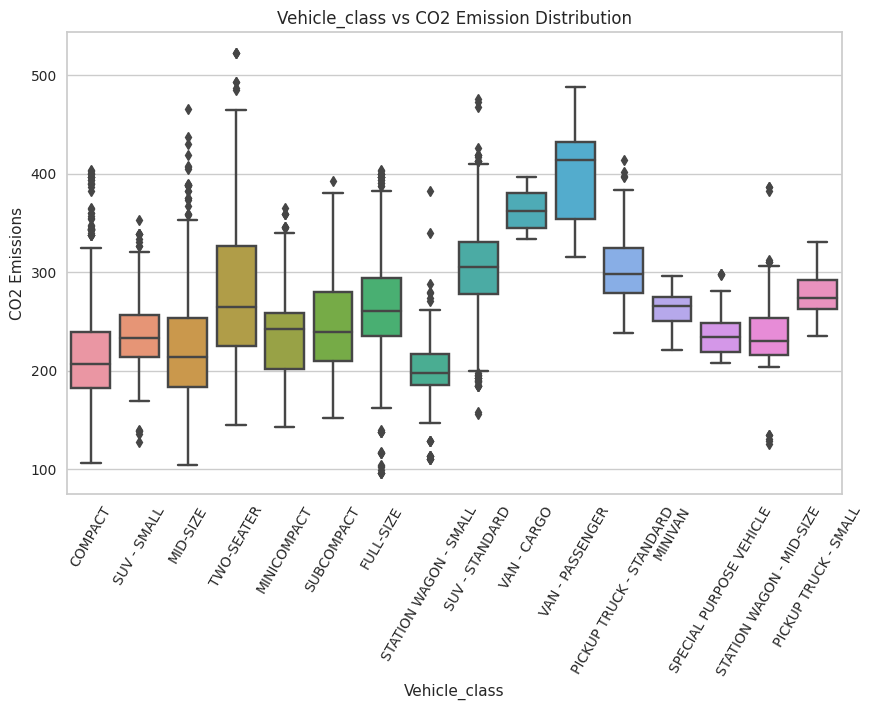

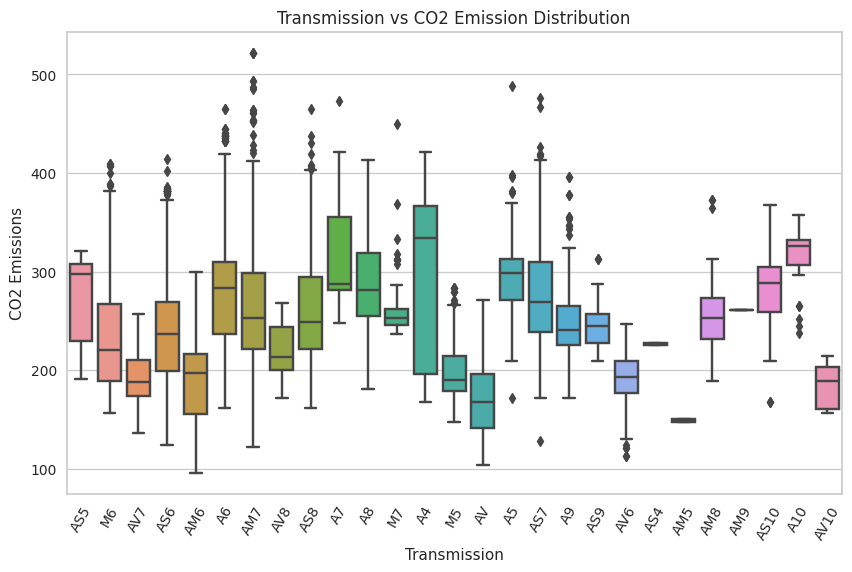

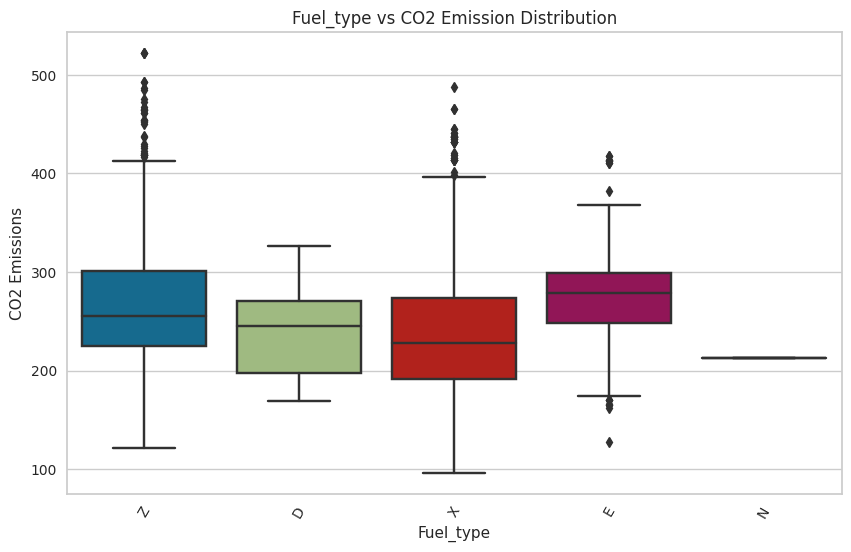

In [26]:


# List of categorical columns
categorical_columns = ['vehicle_class', 'transmission', 'fuel_type']

# Create boxplots for each categorical column with a numerical column (e.g., 'co2')
for cat_col in categorical_columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=cat_col, y='co2', data=df)
    plt.title(f'{cat_col.capitalize()} vs CO2 Emission Distribution')
    plt.xlabel(cat_col.capitalize())
    plt.ylabel('CO2 Emissions')
    plt.xticks(rotation=60, fontsize=10)
    plt.show()


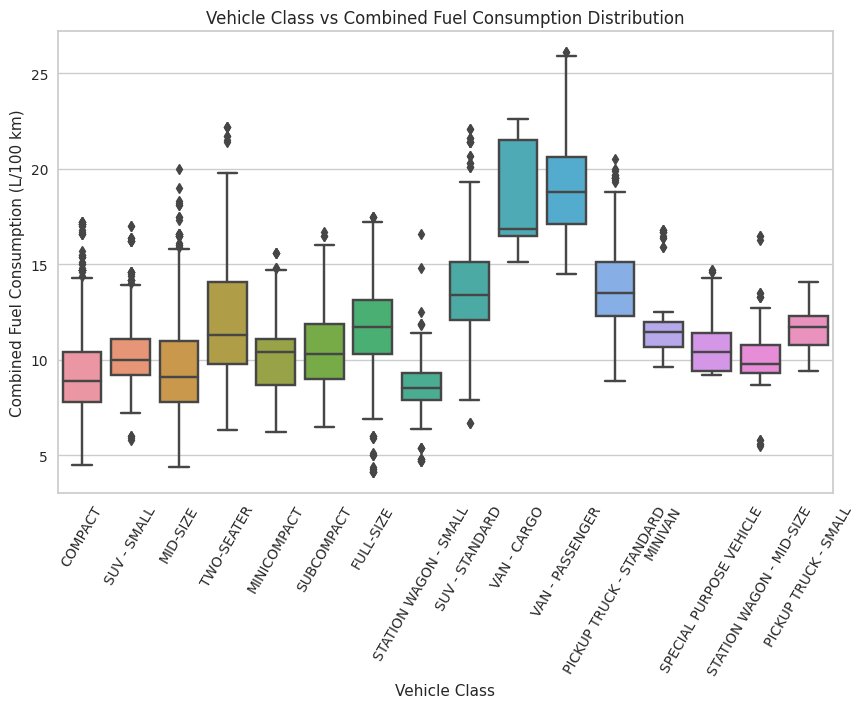

In [27]:

# Create a boxplot for 'vehicle_class' vs 'fuel_cons_comb'
plt.figure(figsize=(10,6))
sns.boxplot(x='vehicle_class', y='fuel_cons_comb', data=df)
plt.title('Vehicle Class vs Combined Fuel Consumption Distribution')
plt.xlabel('Vehicle Class')
plt.ylabel('Combined Fuel Consumption (L/100 km)')
plt.xticks(rotation=60, fontsize=10)
plt.show()


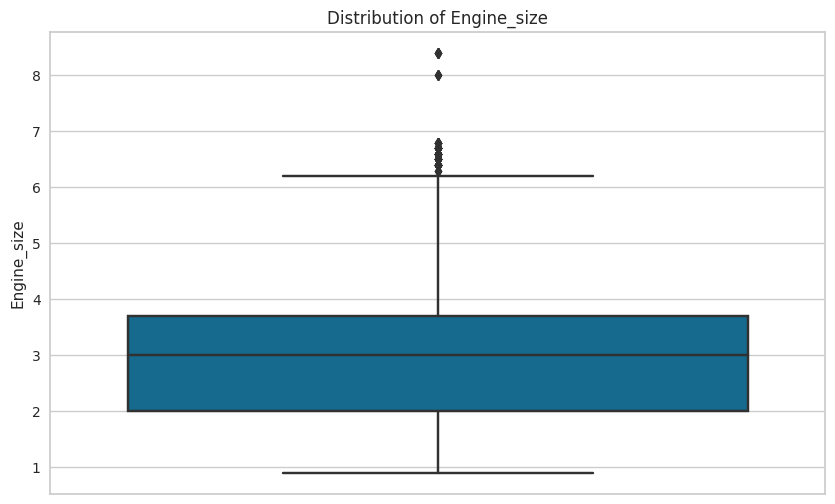

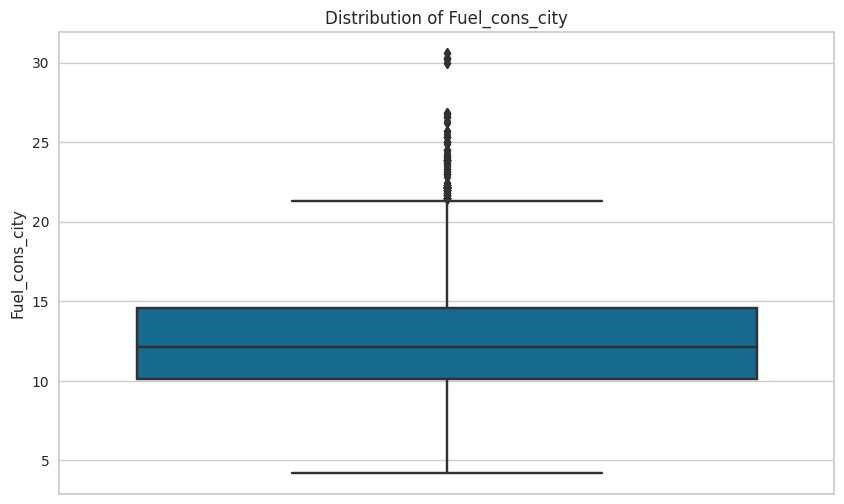

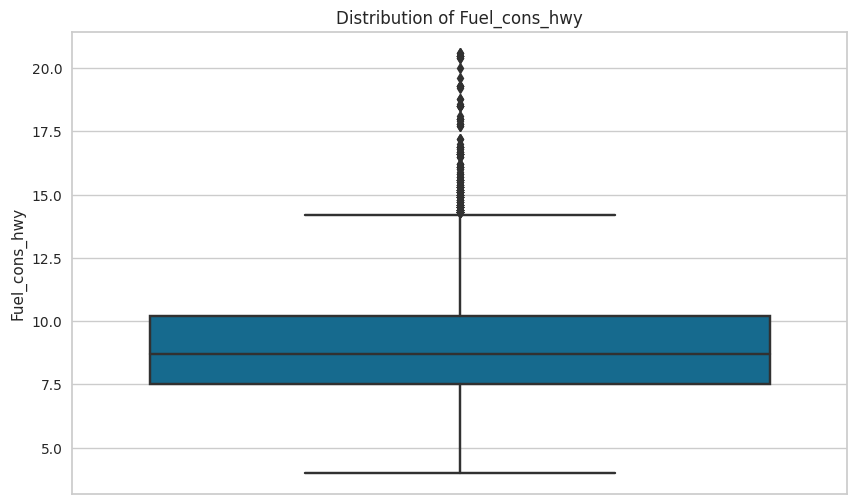

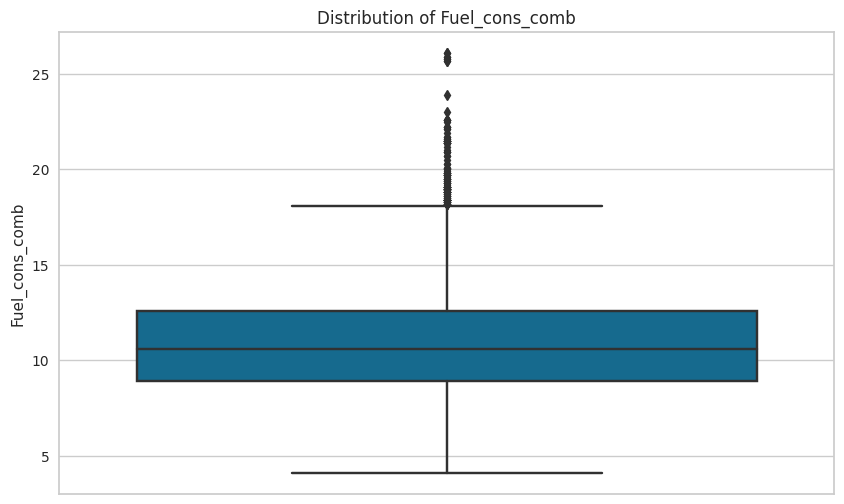

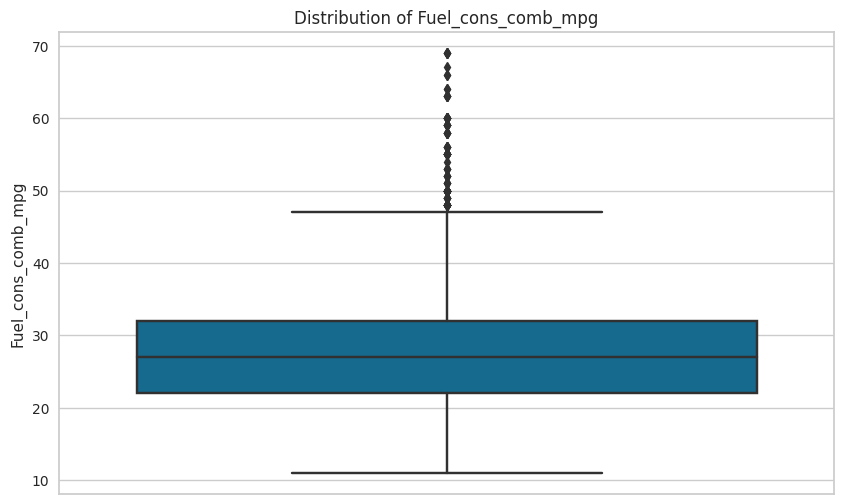

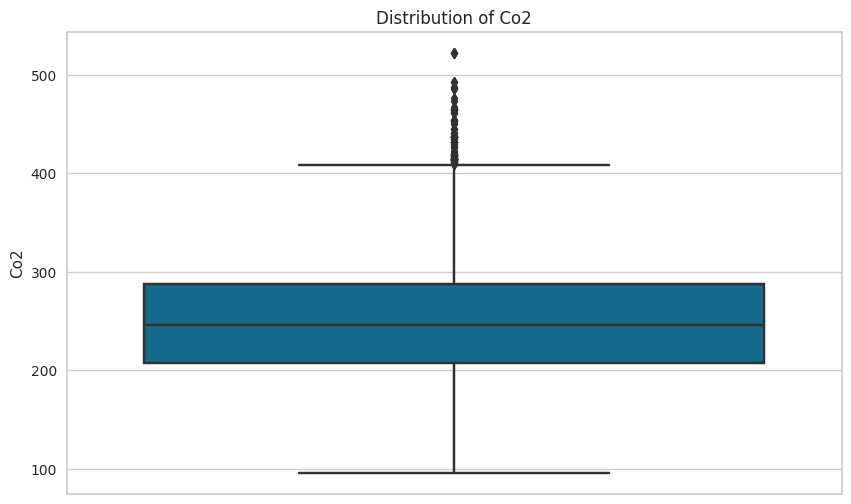

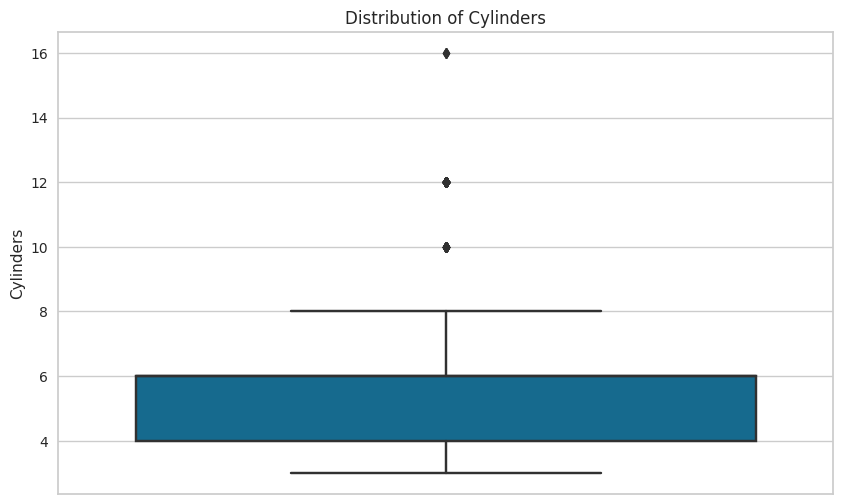

In [28]:

# List of numerical columns
numerical_columns = ['engine_size', 'fuel_cons_city', 'fuel_cons_hwy', 'fuel_cons_comb', 'fuel_cons_comb_mpg', 'co2','cylinders']

# Create boxplots for each numerical column
for num_col in numerical_columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(y=df[num_col])
    plt.title(f'Distribution of {num_col.capitalize()}')
    plt.ylabel(num_col.capitalize())
    plt.show()



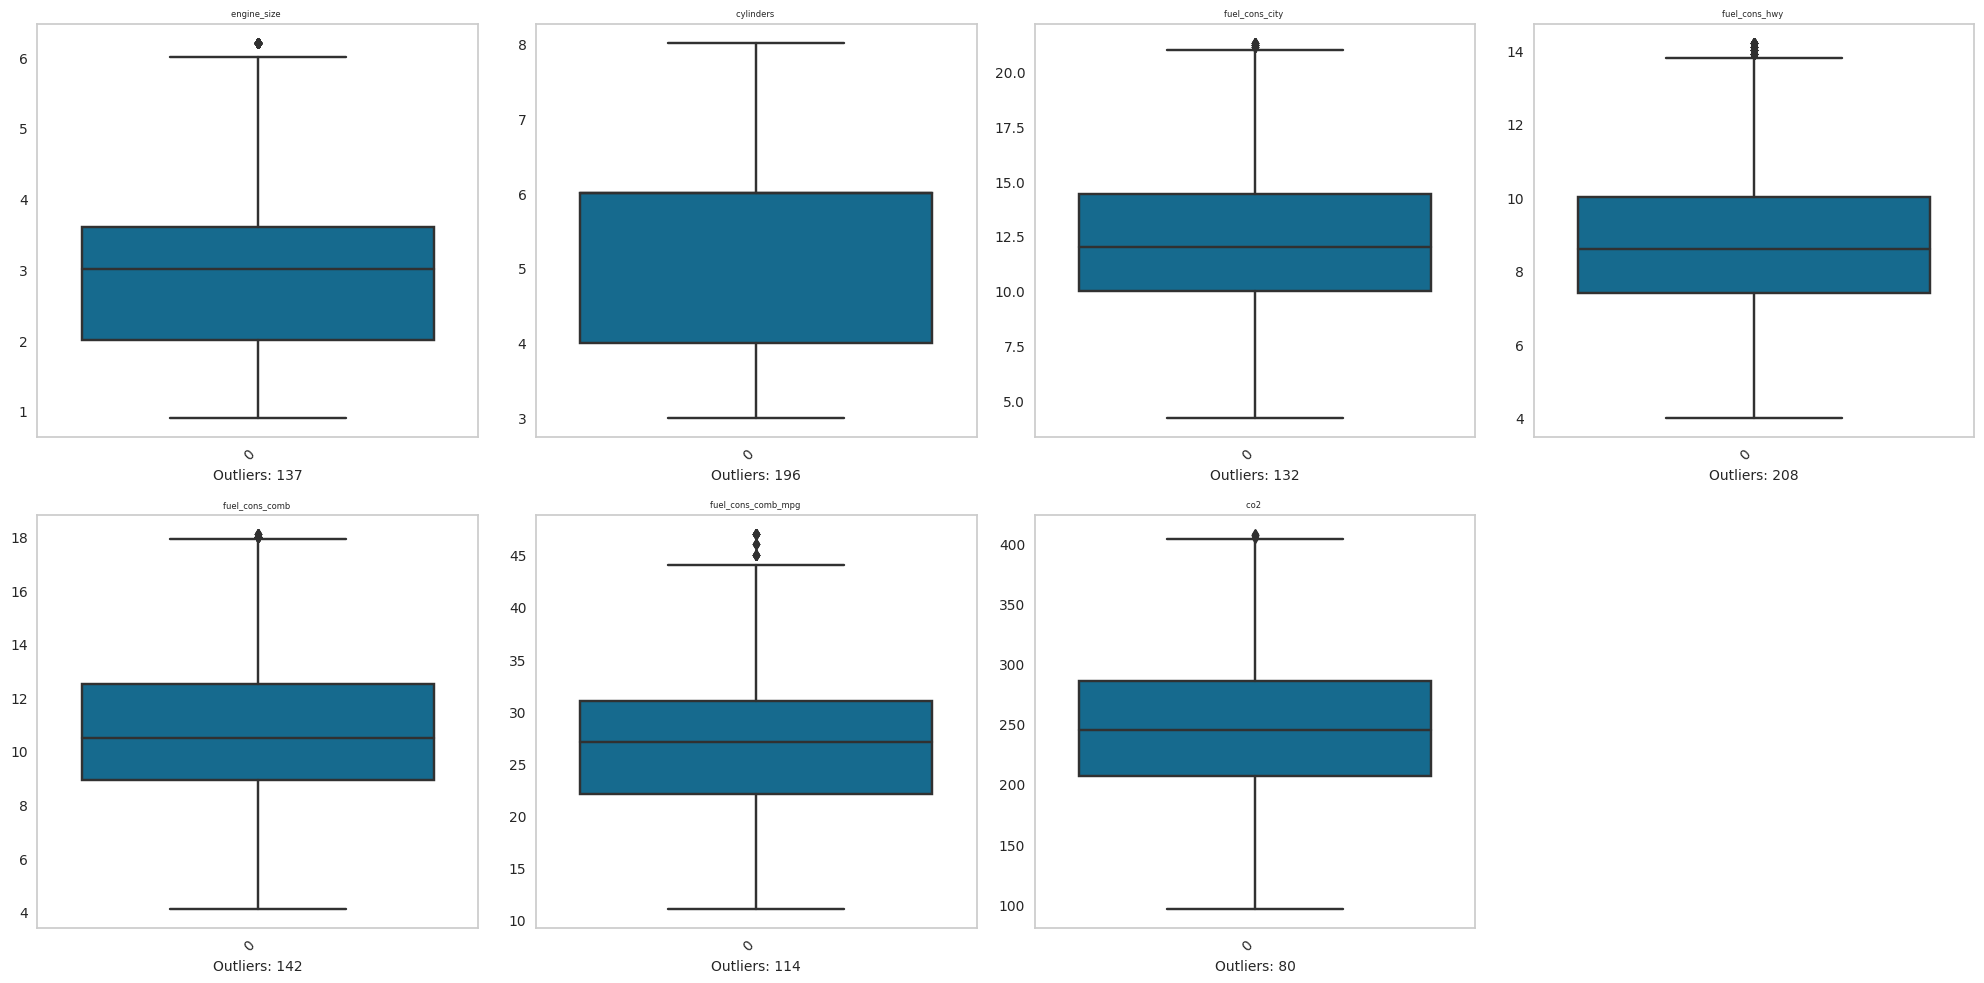

In [29]:


# Calculate the number of rows needed for subplots
num_plots = len(df.select_dtypes(include=['number']).columns)
num_cols = 4  # You can set this to any number of columns you want per row
num_rows = (num_plots // num_cols) + (num_plots % num_cols > 0)  # Ensure the last row is added if needed

# Create a figure with dynamic subplot size
plt.figure(figsize=(num_cols * 5, num_rows * 5))

x = 0
for col in df.select_dtypes(include=['number']).columns:
    # Calculate the 1st quartile (Q1) and 3rd quartile (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Compute the IQR (Interquartile Range)
    IQR = Q3 - Q1
    
    # Determine the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out the outliers
    df_no_outliers = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    # Plot the boxplot
    x += 1
    plt.subplot(num_rows, num_cols, x)
    sns.boxplot(data=df_no_outliers[col])
    plt.title(f'{col} ', fontsize=6)
    
    # Display the number of outliers
    num_outliers = df.shape[0] - df_no_outliers.shape[0]
    plt.xlabel(f'Outliers: {num_outliers}', fontsize=10)
    
    # Additional styling adjustments
    plt.grid(False)  # Remove background grid lines
    plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x-axis labels

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.4, hspace=0.6)  # wspace: Controls horizontal spacing, hspace: Controls vertical spacing

# Optimize layout for better visualization
plt.tight_layout()  # Ensures proper spacing of subplots
plt.show()


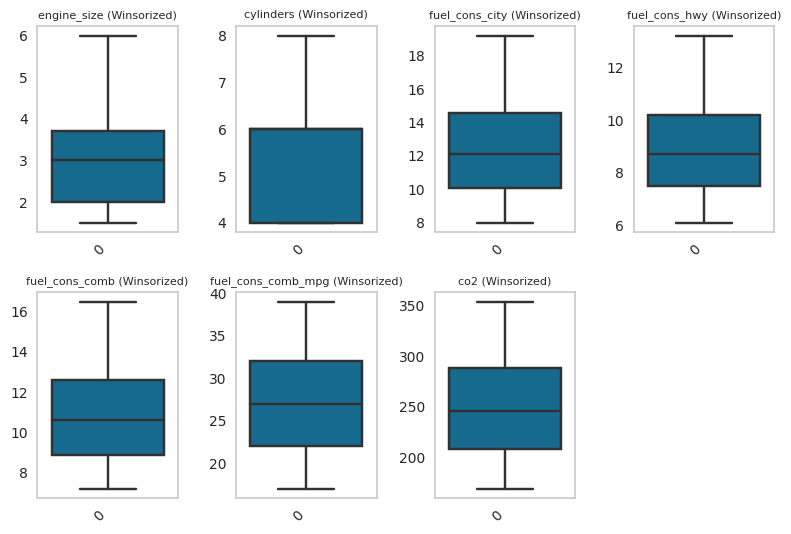

In [30]:
from scipy.stats import mstats

# Select numerical columns from the dataset
numerical_cols = df.select_dtypes(include=['number']).columns

# Determine the number of boxplots
num_plots = len(numerical_cols)

# Set up subplot layout (use a larger grid if necessary)
cols = 4  # 4 plots per row
rows = (num_plots // cols) + (num_plots % cols > 0)  # Calculate the required number of rows

# Apply Winsorization (limit outliers to a specific range)
x = 0  # Subplot index
for col in numerical_cols:
    # Apply Winsorization (limit lower and upper 5%)
    df[col] = mstats.winsorize(df[col], limits=[0.05, 0.05])
    
    x += 1
    plt.subplot(rows, cols, x)  # Dynamically adjust subplots
    sns.boxplot(data=df[col])
    plt.title(f'{col} (Winsorized)', fontsize=8)
    
    # Additional styling adjustments
    plt.grid(False)
    plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x-axis labels

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3)  # wspace: Controls horizontal spacing, can be adjusted

# Optimize layout for better visualization
plt.tight_layout()
plt.show()

In [31]:
from sklearn.preprocessing import LabelEncoder

# Kategorik sütunları seçme
categorical_columns = ['vehicle_class', 'transmission', 'fuel_type','make','model']

# LabelEncoder
label_encoder = LabelEncoder()

# Kategorik sütunları dönüştürme (NaN değerlerini önce temizleyelim)
for col in categorical_columns:
    # NaN değerlerini temizle (veya uygun bir şekilde doldurun)
    df[col] = df[col].fillna('Unknown')  # NaN değerlerini 'Unknown' ile dolduruyoruz
    df[col] = label_encoder.fit_transform(df[col])

# Sonuçları kontrol etme
print(df[categorical_columns].head())


   vehicle_class  transmission  fuel_type  make  model
0              0            14          4     0   1057
1              0            25          4     0   1057
2              0            22          4     0   1058
3             11            15          4     0   1233
4             11            15          4     0   1499


In [32]:
def color_correlation1(val):
    """
    Takes a scalar and returns a string with
    the css property in a variety of color scales 
    for different correlations.
    """
    if val >= 0.6 and val < 0.99999 or val <= -0.6 and val > -0.99999:
        color = 'red'
    elif val < 0.6 and val >= 0.3 or val > -0.6 and val <= -0.3:
        color = 'blue'
    elif val == 1:
        color = 'green'    
    else:
        color = 'black'
    return 'color: %s' % color

# Create a DataFrame containing only numeric data
numeric_df = df.select_dtypes(include=[np.number])

# Calculate and style correlation on numeric DataFrame
numeric_df.corr().style.applymap(color_correlation1)

# - If the correlation coefficient is between `0.6` and `0.99999` or between `-0.6` and `-0.99999`, the color is `red`.
# This indicates a strong correlation (positive or negative).
# - If the correlation coefficient is between `0.3` and `0.6` or between `-0.3` and `-0.6`, the color is `blue`.
# This indicates a moderate correlation.
# - If the correlation coefficient is exactly `1`, the color is `green`. This indicates perfect positive correlation.
# - For all other cases the color will be `black`, indicating weak or no correlation.

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb,fuel_cons_comb_mpg,co2
make,1.000000,0.012679,-0.029558,-0.151214,-0.181052,0.181923,0.045368,-0.198756,-0.123237,-0.174253,0.182635,-0.157923
model,0.012679,1.000000,0.190713,0.072182,0.057223,-0.016260,-0.079554,0.106668,0.170797,0.129700,-0.116103,0.121690
vehicle_class,-0.029558,0.190713,1.000000,0.147510,0.128357,-0.156562,-0.033560,0.224036,0.321480,0.258756,-0.272059,0.277762
engine_size,-0.151214,0.072182,0.147510,1.000000,0.942464,-0.331436,0.049633,0.856402,0.792870,0.844440,-0.816769,0.864209
cylinders,-0.181052,0.057223,0.128357,0.942464,1.000000,-0.296015,0.098239,0.830863,0.762244,0.816641,-0.798617,0.848230
transmission,0.181923,-0.016260,-0.156562,-0.331436,-0.296015,1.000000,0.212872,-0.350560,-0.356616,-0.356087,0.359279,-0.329190
fuel_type,0.045368,-0.079554,-0.033560,0.049633,0.098239,0.212872,1.000000,-0.044373,-0.079919,-0.056635,-0.016524,0.095057
fuel_cons_city,-0.198756,0.106668,0.224036,0.856402,0.830863,-0.350560,-0.044373,1.000000,0.948832,0.993935,-0.965645,0.929940
fuel_cons_hwy,-0.123237,0.170797,0.321480,0.792870,0.762244,-0.356616,-0.079919,0.948832,1.000000,0.976917,-0.948816,0.913375
fuel_cons_comb,-0.174253,0.129700,0.258756,0.844440,0.816641,-0.356087,-0.056635,0.993935,0.976917,1.000000,-0.970457,0.935114


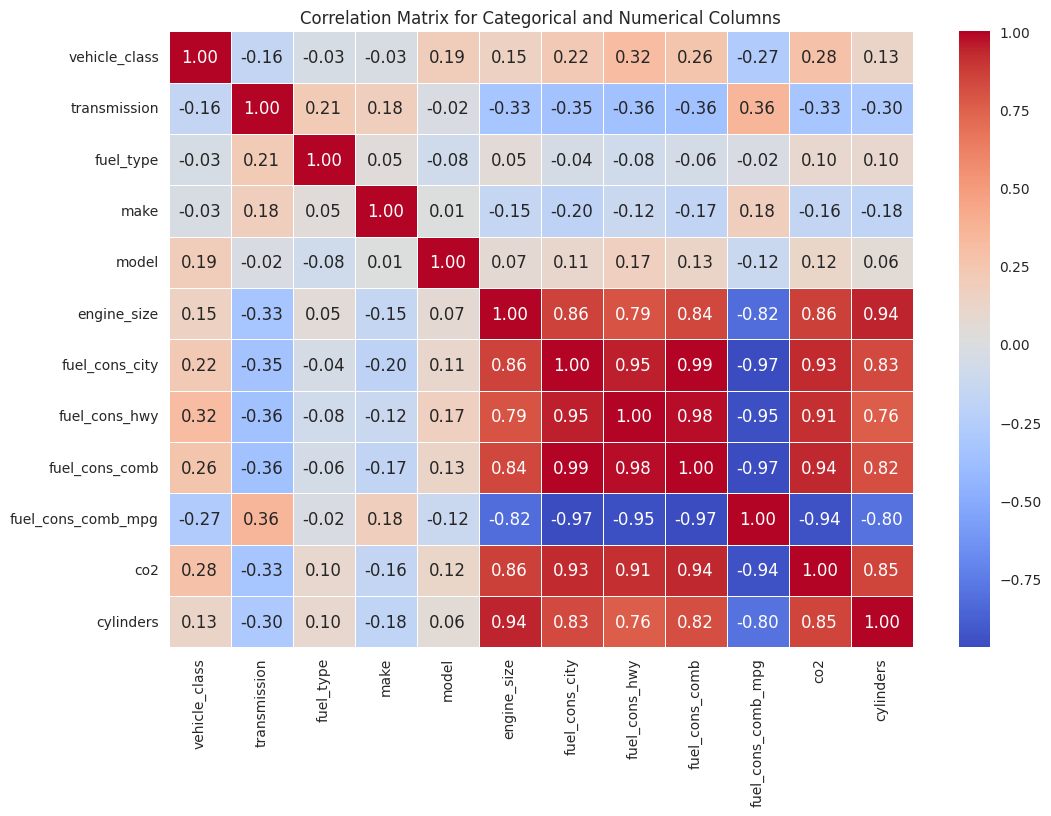

In [33]:
# Select categorical columns
categorical_columns = ['vehicle_class', 'transmission', 'fuel_type','make','model']
numerical_columns = ['engine_size', 'fuel_cons_city', 'fuel_cons_hwy', 'fuel_cons_comb', 'fuel_cons_comb_mpg', 'co2','cylinders' ]

# Convert categorical columns to numerical data (Label Encoding)
label_encoder = LabelEncoder()

# Transform categorical columns
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Create correlation matrix with categorical and numerical columns
correlation_matrix = df[categorical_columns + numerical_columns].corr()

# Visualizing the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Categorical and Numerical Columns')
plt.show()

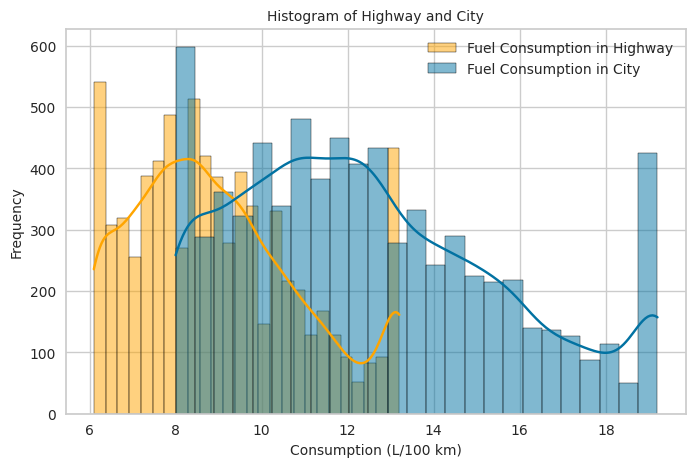

In [34]:
# Consumption of Highway and City

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="fuel_cons_hwy", kde=True, label = "Fuel Consumption in Highway",color = "orange")
sns.histplot(data=df, x="fuel_cons_city", kde=True, label = "Fuel Consumption in City")
plt.xlabel('Consumption (L/100 km)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title(f'Histogram of Highway and City', fontsize=10)
plt.legend()
plt.show()

1. **Engine Size (engine_size):** The distribution is skewed with several peaks, indicating different types of vehicles with varying engine sizes.
2. **Cylinders:** The distribution is concentrated around specific values (4, 6, 8), reflecting common engine types in the dataset.
3. **Fuel Consumption City (fuel_cons_city):** The distribution is approximately normal, which is beneficial for model learning.
4. **Fuel Consumption Hwy (fuel_cons_hwy):** Similar to city fuel consumption, this also shows an approximately normal distribution.
5. **Fuel Consumption Combined (fuel_cons_comb):** The combined fuel consumption distribution is normal, making it a useful variable for modeling.
6. **Fuel Consumption MPG (fuel_cons_mpg):** This shows a normal distribution and has an inverse relationship with other fuel consumption metrics, which is expected.
7. **CO2 Emissions (co2):** The distribution is nearly normal, which is advantageous for regression models.

**Overall Evaluation:**
- Most features exhibit normal or skew-normal distributions, which are suitable for modeling.
- Consider multicollinearity, especially among `fuel_cons_City`, `fuel_cons_Hwy`, and `fuel_cons_Comb`.
- Features like `cylinders`, `engine_size`, and `fuel_cons_mpg` provide important information about vehicle performance and efficiency, making them valuable for the model.

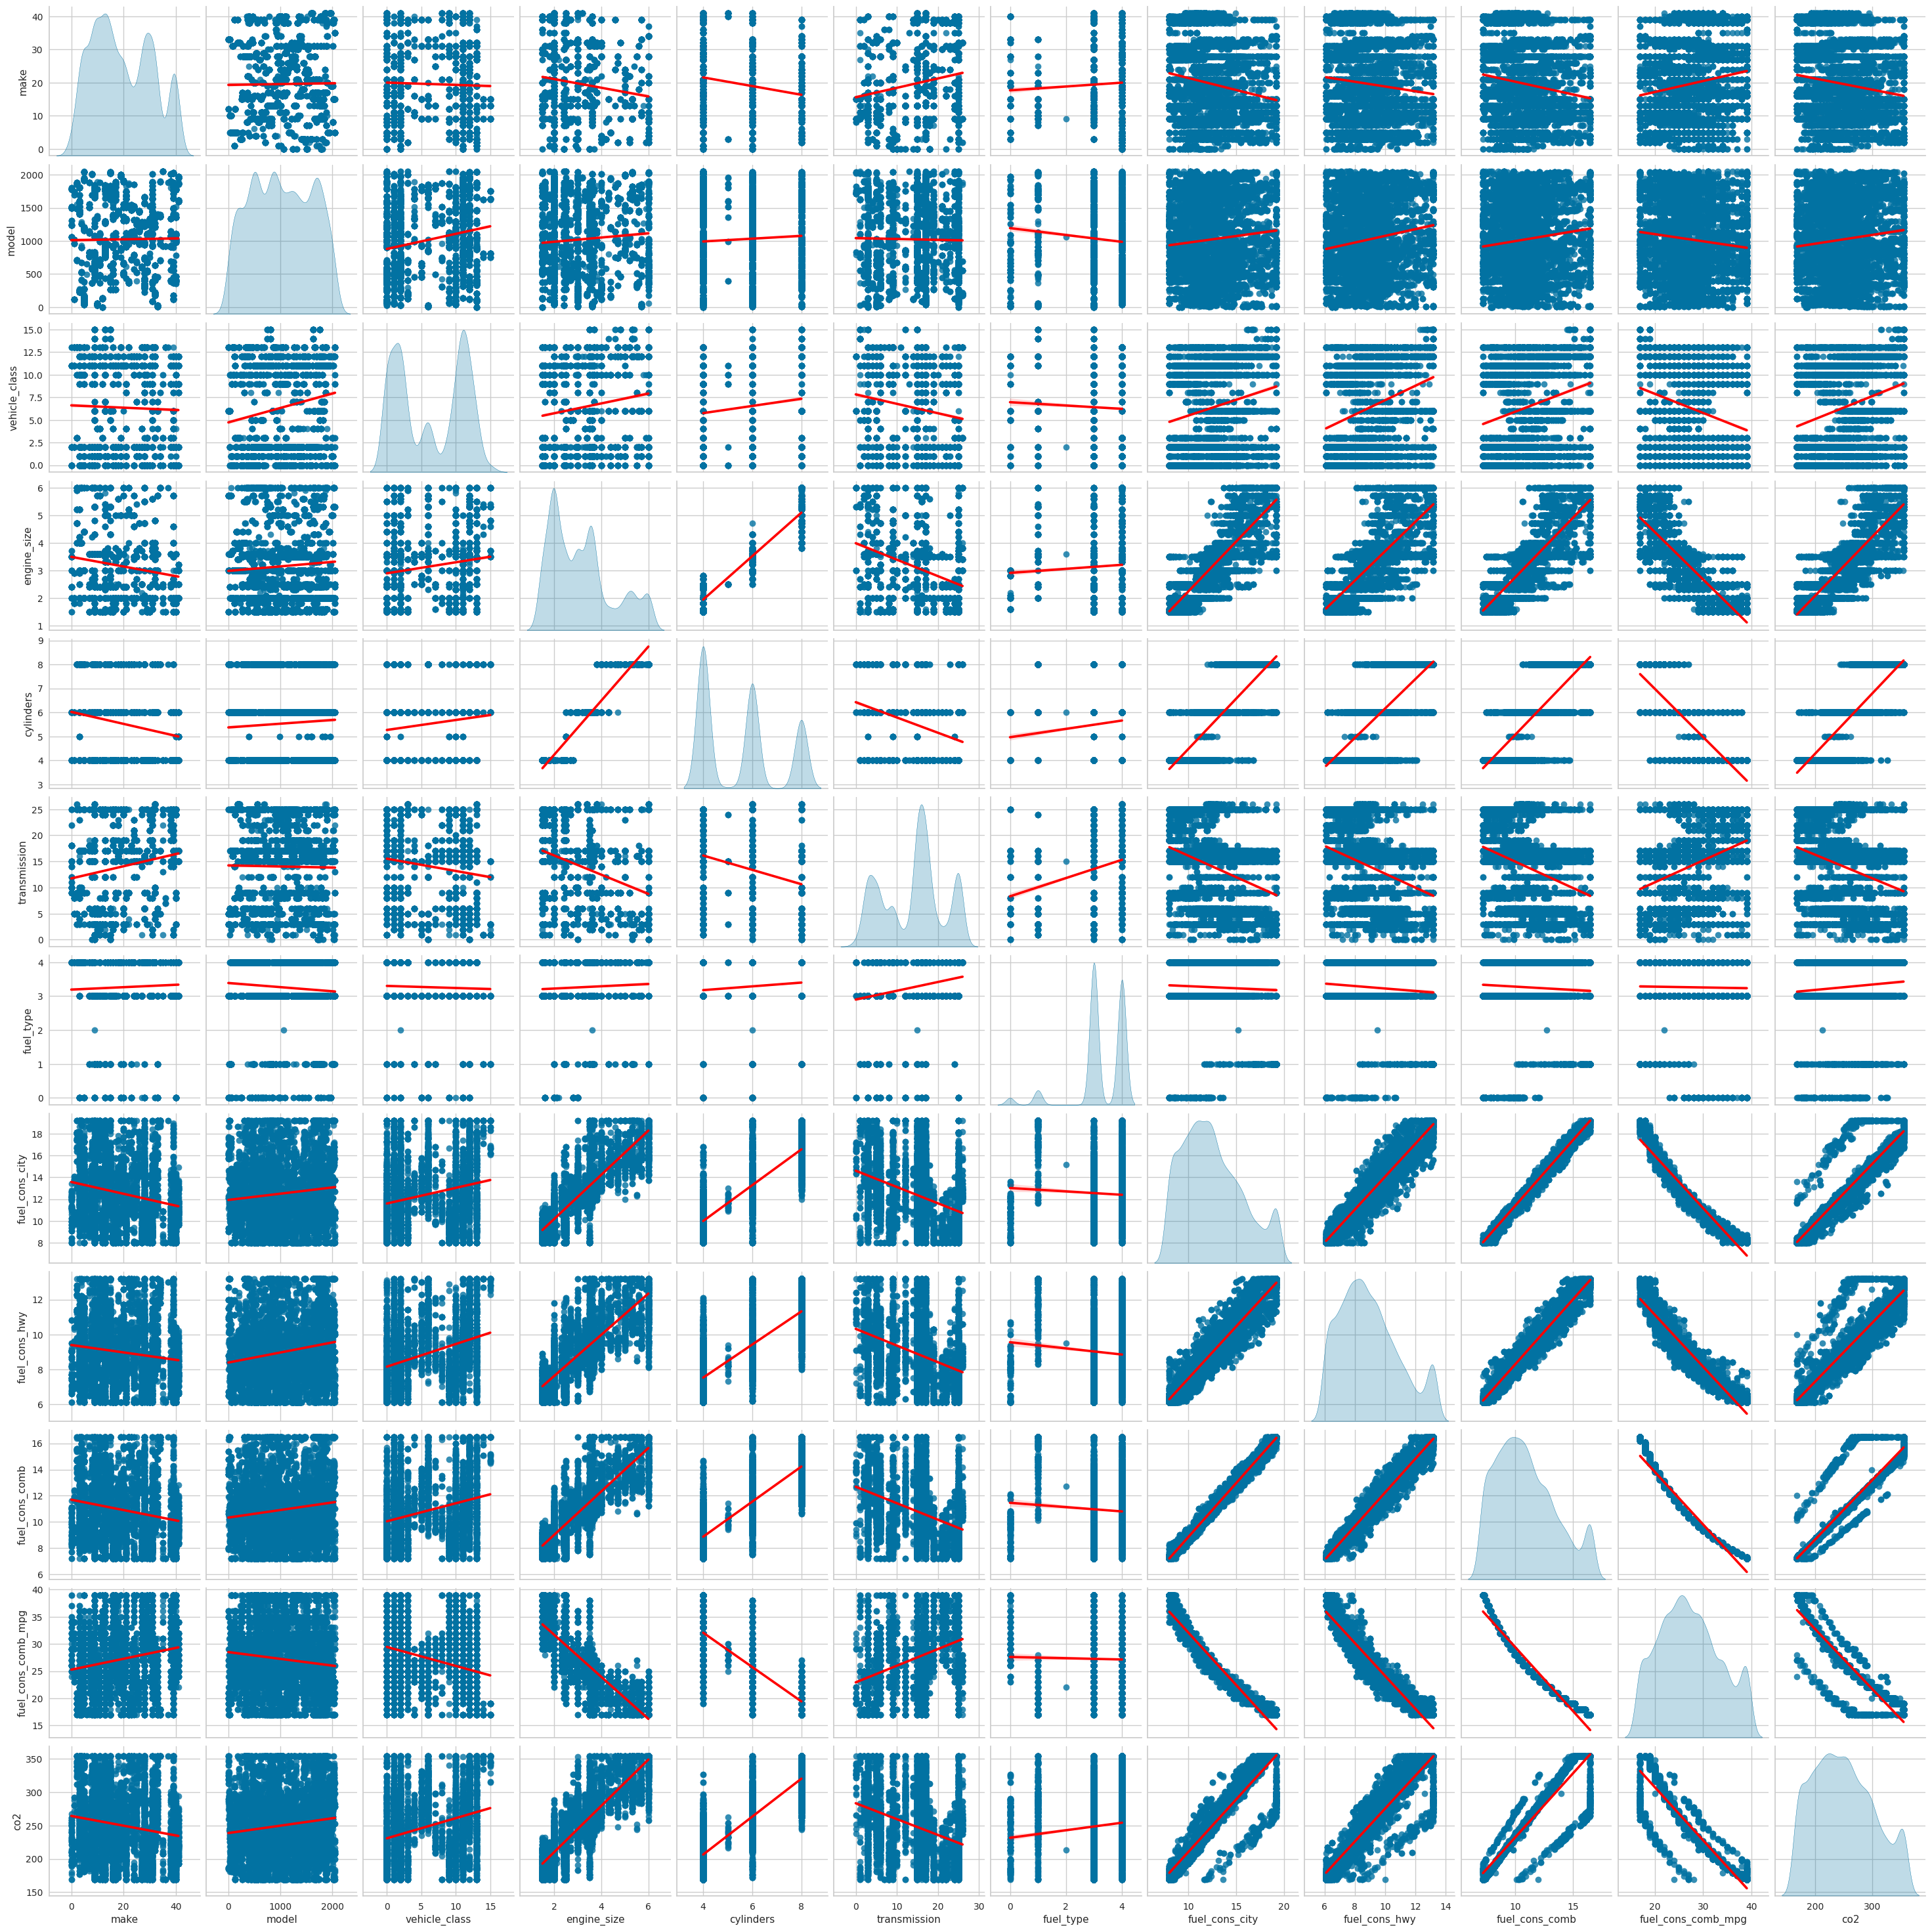

In [35]:
# Pairplot for the dataframe

sns.pairplot(df,
             kind="reg",
             diag_kind="kde", 
             plot_kws={"line_kws": {"color": "red"}}
            )

The pairplot shows the relationships and distributions between various numerical features in the dataset. Here's a brief analysis:

1. **Engine Size (engine_size):**
   - Positively correlated with `cylinders`, `fuel_cons_city`, `fuel_cons_hwy`, `fuel_cons_comb`, and `co2`.
   - Larger engines tend to have more cylinders and higher fuel consumption.

2. **Cylinders:**
   - Strong positive correlation with `engine_size` and fuel consumption metrics.
   - As the number of cylinders increases, fuel consumption and CO2 emissions also increase.

3. **Fuel Consumption City (fuel_cons_City):**
   - High positive correlation with `fuel_cons_hwy`, `fuel_cons_comb`, and `co2`.
   - Vehicles that consume more fuel in the city tend to consume more on highways and produce higher CO2 emissions.

4. **Fuel Consumption Hwy (fuel_cons_Hwy):**
   - Similar correlations as city fuel consumption, showing strong positive relationships with `fuel_cons_city`, `fuel_cons_comb`, and `co2`.

5. **Fuel Consumption Combined (fuel_cons_Comb):**
   - Very high correlation with both city and highway fuel consumption.
   - Indicative of overall vehicle efficiency.

6. **Fuel Consumption MPG (fuel_cons_mpg):**
   - Shows a strong negative correlation with other fuel consumption metrics and `co2`.
   - ***Higher MPG values indicate better fuel efficiency and lower CO2 emissions.***
   - fuel efficiency increases (mpg value increases), CO2 emissions decrease.
   
7. **CO2 Emissions (co2):**
   - Strongly correlated with `engine_size`, `cylinders`, `fuel_cons_city`, `fuel_cons_hwy`, and `fuel_cons_comb`.
   - ***Vehicles with larger engines, more cylinders, and higher fuel consumption emit more CO2***.

**Overall Evaluation:**
- The pairplot reveals strong relationships among features, particularly between engine size, fuel consumption, and CO2 emissions.
- The negative correlation between MPG and other features highlights its importance in representing fuel efficiency.
- Suggest focusing on features like `fuel_cons_comb`, `engine_size`, and `fuel_cons_mpg` for predictive modeling, while considering multicollinearity.

# <font color='#3D8D7A'> <b>MACHINE LEARNING</b><font color='black'>


#### Objective of CO₂ Emission Modeling

The goal of creating and using a model with the CO₂ emission dataset is to build **machine learning algorithms** capable of accurately predicting vehicle CO₂ emissions based on their characteristics.

#### Key Aspects:
- **Feature Analysis**: By examining variables such as **engine size, number of cylinders, and fuel consumption**, the model aims to evaluate the environmental impact of different vehicles.
- **Policy Implications**: The insights derived can guide **policy decisions** aimed at reducing carbon emissions.
- **Industry & Consumer Support**: 
  - Helps **automotive manufacturers** in designing more fuel-efficient vehicles.  
  - Assists **consumers** in selecting vehicles with **lower carbon footprints**.

#### **Final Goal**
Leveraging **data-driven insights** to **mitigate environmental impact**, **promote sustainable development**, and contribute to a **greener future**.

**Evaluating model accuracy on both training and test sets is essential** to determine whether the model is **overfitting or underfitting** the data, effectively addressing the **bias-variance tradeoff**.



# <font color='#3D8D7A'> <b>SIMPLE LINEAR REGRESSION MODEL</b><font color='black'>

#### Linear Regression

Linear regression predicts the dependent variable based on independent variables.

- If there is only one independent variable, it's called simple linear regression.
- If there are multiple independent variables, it is called multiple linear regression.

In **simple linear regression**, if there is a significant relationship between the feature and the target, then this data is suitable for linear regression.

#### Basic Assumptions of Linear Regression Analysis

1. **Linear Relationship Assumption:** It is assumed that the relationship between the dependent variable and the independent variables can be expressed in a linear way. That is, the relationship between the variables should be linear. For example, as X increases, Y should either increase or decrease.

2. **Independence Assumption:** It is assumed that the observations are independent. In other words, the result of one observation should not affect other observations.

3. **Normal Distribution Assumption:** The error terms (residuals) should be normally distributed and should not form any patterns. This is necessary for the regression model's predictions to be reliable.

4. **Independence of Independent Variables:** There should be no multicollinearity problem among the independent variables. In other words, the independent variables should not be highly correlated with each other.

- **Ŷ = b₀ + b₁X**

  - **Ŷ** = predicted value
  - **b₀** = intercept (the point where the line crosses the y-axis)
  - **b₁** = slope = coefficient = weight
  - **X** = independent variable
  - **Residual** = Random error = e = Y - Ŷ

#### The key is to minimize the error.

**Best Fit Line**: The line that minimizes our errors. In the case of a single feature, the **Ordinary Least Squares** method is used, and for multiple features, **gradient descent** is applied.

**Cost - Loss Function**: This function calculates the average error by squaring the difference between the actual and predicted values.

**Gradient Descent**: The optimization algorithm adjusts the values of w and b gradually, trying to minimize the cost-loss function and get it as close to the minimum value as possible.

It is an iterative algorithm that minimizes the error.

#### Bias and Variance

- **Bias**: Bias is the systematic error in a model's predictions. The higher the bias, the farther the model’s predictions are from the actual values. High bias can occur when the model is too simple and unable to capture the complexity of the data, which leads to underfitting.

- **Variance**: Variance refers to how much the model's predictions vary across different data points. If a model is trained multiple times on the same dataset and yields different results, it has high variance. High variance indicates that the model has overfitted the data, meaning it cannot generalize well to new data outside of the training set.

#### Bias-Variance Trade-off

It is important to strike a balance between bias and variance. Ideally, a model should have both low bias and low variance. This means the model should be able to capture the complexity of the data while also generalizing well to unseen data.


In [36]:
corr = df.co2.corr(df.engine_size)
corr

# Correlation shows the relationship between features. It provides us with an inference about whether the features decrease/increase together or whether one decreases/increases while the other increases/decreases.

# But correlation does not provide an inference about how much a 1 unit increase in engine_size in our data affects CO2 emissions
# (increases or decreases). It only provides information that CO2 emissions increase if engine_size increases.
# Here, we will find the answer to how much CO2 emissions will increase/decrease with increases/decreases of 1 unit or more with regression

0.8642088242423

#### R-Squared (R², The Coefficient of Determination)

R-squared answers the question: **How much of the change in the target variable can be explained by the available features?**  
It helps us understand how much information we have to correctly predict the target variable.

- R² takes values between **0 and 1**.
- As R² approaches **1**, the model's accuracy increases.
- A **negative R² score** indicates that the model is misleading rather than explaining the data, showing poor performance.  
  - In this case, the data may need to be modeled with a different approach or a different set of features.

#### R-Squared Formula

\[
R^2 = 1 - \frac{SSR}{SST}
\]

#### Components of the Formula

- **SSR (Residual Sum of Squares):**  
  - SSR is the sum of the squares of the differences between the actual values and the predicted values.  
  - It is calculated as:  
    \[
    SSR = \sum (y - \hat{y})^2
    \]
  - **Interpretation:**  
    - Represents how much the model is off.
    - A **low SSR value** indicates that the model makes predictions close to the actual values.

- **SST (Total Sum of Squares):**  
  - SST is the sum of the squared differences between the actual values and the mean of the actual values.  
  - It is calculated as:  
    \[
    SST = \sum (y - \bar{y})^2
    \]
  - **Interpretation:**  
    - Represents the total variability in the data.
    - This is the maximum variability the model should capture.

#### Understanding R²:

- **If R² is close to 1:**  
  - The model explains most of the variability in the target variable.
  
- **If R² is close to 0:**  
  - The model does not explain much of the variance in the target variable.

- **If R² is negative:**  
  - The model performs worse than simply using the mean as a predictor.
  - A different modeling approach or feature selection may be required.

#### Summary:

- **R² measures how well the model explains the variance in the target variable.**
- **A higher R² value indicates a better model fit.**
- **A negative R² means the model is performing poorly and might need improvements.**



In [37]:
r2_score = corr**2
r2_score

0.7468568918982587

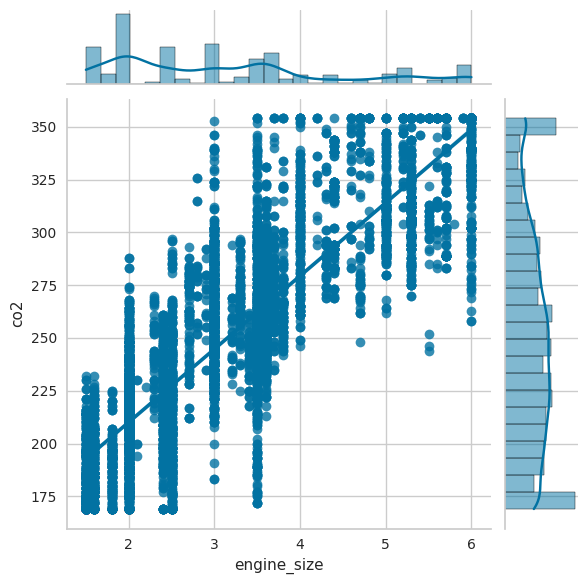

In [38]:
sns.jointplot(y=df['co2'], x=df['engine_size'],  kind='reg');

# jointplot also shows the joint distribution of variables and their individual histograms. default scatter

# regplot is similar to scatterplot but adds a regression line. This regression line is used to visualize the relationship between two variables
# Our main goal is to create a point for each observation in the dataset and place these points on a plane to understand or discover the relationship between two numerical variables.
# What it actually does is, it plots a point on the x and y axes for each observation, helping to visualize the nature, direction, intensity and distribution of the relationship between the two variables.
# For example, scatter plots can be used to answer questions such as whether the relationship between two variables is linear or nonlinear, positive or negative.
# It can also be used to identify outliers or groups in the dataset

### <font color='#3D8D7A'> <b>SPLITTING THE DATA</b><font color='black'>


In [39]:
# Split the selected independent feature (engine_size) and target variable (co2_emissions) for SIMPLE Linear Regression

X = df[['engine_size']] 
y = df['co2'] 

### <font color='#3D8D7A'> <b>TRAIN | TEST SPLIT</b><font color='black'>


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Default test_size=0.25.
# Best practice values ​​around 0.2, 0.25, 0.3 are preferred. The aim here is to provide as much data as possible to the train set. Especially for small data, this ratio can be selected around 0.1, 0.15

# With random_state, we randomly distribute the data to train and test and send the same data to
# train and test each time

In [41]:
# Display the shapes of the resulting datasets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5908, 1)
X_test shape: (1477, 1)
y_train shape: (5908,)
y_test shape: (1477,)


In [42]:
X_train.head()

,engine_size
6590,3.0
6274,4.0
2251,3.0
3149,3.4
4362,2.0



## <font color='#3D8D7A'> <b>Training the Model</b><font color='black'>

In [43]:
from sklearn.linear_model import LinearRegression  

# We import the LinearRegression algorithm.

In [44]:
slr = LinearRegression()  # object definition

# We always assign our algorithm to a variable. Otherwise, we will get an error while making predictions.

In [45]:
slr.fit(X_train, y_train) 

# train the model according to linear regression by giving the data

# If we write LinearRegression() instead of model, the code will work. However, if you use LinearRegression()
# while getting the prediction below, you will get an error. To avoid this error, we definitely make the assignment model =LinearRegression()


LinearRegression()

**Meanings of Coefficients**

1. **Positive Coefficient**:

- If the coefficient of an independent variable is positive, this indicates that when the value of that variable increases, the target variable (the predicted variable) will also increase.
- For example, there may be a positive relationship between the size of a house and its price: As the size of the house increases, its price also increases.

2. **Negative Coefficient**:

- If the coefficient of an independent variable is negative, this indicates that when the value of that variable increases, the target variable will decrease.
- For example, there may be a negative relationship between the age of a vehicle and its value: As the vehicle ages, its value decreases.

**Magnitude of Coefficients**

- **Higher Absolute Value**: The larger the absolute value of a coefficient (regardless of whether it is positive or negative), the greater the effect of the relevant independent variable on the target variable.
- **Low or Near Zero Value**: If a coefficient is low or near zero, it indicates that the effect of the independent variable on the target variable is weak or insignificant.

In summary, the coefficients in a linear regression model indicate the effect of the independent variables on the target variable. The coefficients indicate the direction (positive or negative) and magnitude (strength of effect) of this effect. This information is used to understand how the model works and which variables play a significant role in the predictions.

In [46]:
slr.coef_

array([34.51637785])

**Intercept**: In a linear regression equation, the predicted value of the target variable when the values ​​of the independent variables are zero. In other words, it is the point where the regression line intersects the y-axis.

Mathematically, a simple linear regression equation is as follows:

\[ y = mx + b \]

Where:
- \( y \) represents the target variable.
- \( x \) is the independent variable.
- \( m \) is the slope or coefficient (representing the change in the target variable with each unit change in the independent variable).
- \( b \) is the intercept (i.e. the value of \( y \) when \( x = 0 \).

**Importance of Intercept**

- **Interpretation of the Model**: The intercept is the value of the target variable that the model predicts when all of the independent variables are zero. This is especially important when the zero point of the variables has practical significance.

- **Start Point**: The Intercept determines the starting point of the regression line, which indicates the overall trend of the model on the target variable.

The Intercept indicates the overall trend of the model and the effect of the variables on the target variable at the zero point. Therefore, it is a critical component for interpreting and understanding the model.

In [47]:
slr.intercept_

141.38649766329934

### <font color='#3D8D7A'> <b>PREDICTING TEST DATA</b><font color='black'>


In [48]:
y_train_pred = slr.predict(X_train) 
# allows the model to make predictions on the "X_train" dataset. from the data it sees

In [49]:
y_pred = slr.predict(X_test) 
# allows the model to make predictions on the dataset "X_test". from data it has not seen

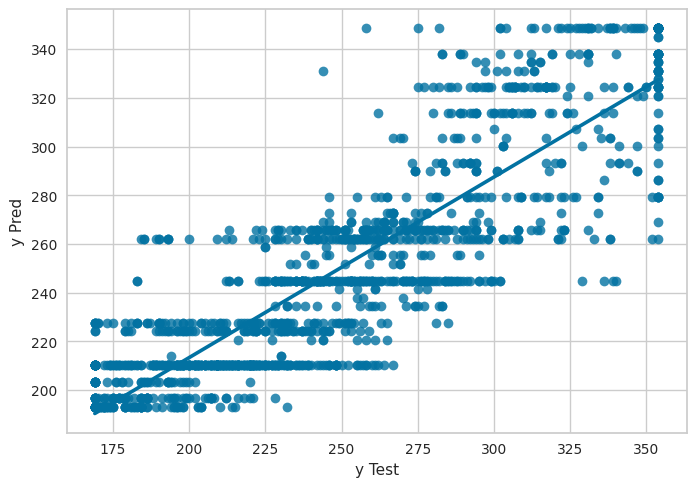

In [50]:
sns.regplot(x=y_test, y=y_pred, ci=None)

plt.xlabel('y Test')
plt.ylabel('y Pred')

plt.show()

### <font color='#3D8D7A'> <b>EVALUATING THE MODEL</b><font color='black'>


#### <font color='#3D8D7A'> <b>Performance Metrics</b><font color='black'>

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def train_val(y_train, y_train_pred, y_test, y_pred, model_name):
    
    scores = {model_name+"_train": {"R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),                          
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},
    
    model_name+"_test": {"R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}}
    
    return pd.DataFrame(scores)

# We define the function above to see all our regression metrics together..

In [52]:
slr_score = train_val(y_train, y_train_pred, y_test, y_pred, "s_linear")
slr_score 

# to compare the metric scores we get from each algorithm, we assign these scores to a variable and then we will concatenate and interpret these scores below.

# first we get our metrics from the test set.
# then we get our metrics from the train set and compare the scores the model gets from data it has never seen with the scores it gets from the training
# data. If the scores are close to each other, it means the model can generalize.
# however, if there are serious differences between the scores, it means the model cannot generalize.

,s_linear_train,s_linear_test
R2,0.745021,0.753897
mae,20.774338,20.219191
mse,699.400297,678.516397
rmse,26.446177,26.048347


**What is RMSE (Root Mean Square Error)?**

- **Calculation of RMSE**: RMSE is the square root of the mean squared error (MSE) obtained by dividing the sum of the squares of the differences (errors or residuals) between the values ​​predicted by the model and the actual values ​​(target) by the number of observations.

- **Meaning and Interpretation**: RMSE gives more weight to large errors by squaring the errors, thus "penalizing" the large errors made by the model. The value obtained by taking the square root expresses the errors in the same units as the values ​​the model is trying to predict. This makes RMSE easier to understand and interpret.

**Why is RMSE Preferred?**

- **Emphasis on the Magnitude of Errors**: RMSE evaluates large errors as more significant than small errors. This better reflects the performance of the model in real-world scenarios because large errors can often lead to more critical results.

- **Error Metric in the Same Unit**: RMSE presents the error metric in the same unit as the unit of the predicted values. This allows a more intuitive evaluation of the model's performance.

**Extra Explanation: Ratio of Errors to Average Values**

- **Significance of Average Values**: By comparing RMSE to the average of the value the model is trying to predict, it is possible to understand how good or bad the overall performance of the model is compared to the overall magnitude of the predicted values. This ratio shows how important the model's errors are compared to the overall magnitude.

**In summary,** RMSE is an error metric used to measure the model's prediction performance, giving more weight to large errors and expressing errors in the same unit as the values ​​predicted by the model. Due to these features, it is often preferred, especially in regression problems. The ratio of RMSE to the average of the value we want to predict is an indicator of the overall performance of the model.

In [53]:
avg_em= df['co2'].mean()
avg_em

249.9385240352065

In [54]:
avg_co2= df['co2'].mean()
avg_co2

249.9385240352065

In [55]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

26.04834729144478

In [56]:
rmse/avg_em
# we are trying to find out how much the error is compared to the average of the target label
# according to the rmse metric, our model makes an average of 12% error.
# We prefer our rmse metric because it penalizes bad predictions. And we inform the customer that our model makes an average of 10% error.

0.10421901702426471

### <font color='#3D8D7A'> <b>RESIDUALS DISTRIBUTIONS</b><font color='black'>

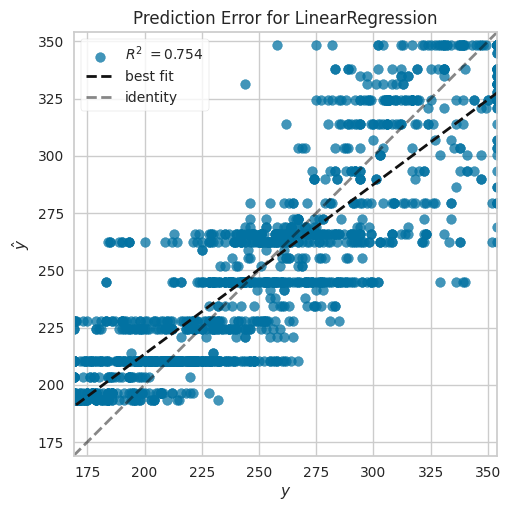

In [57]:
from yellowbrick.regressor import ResidualsPlot
# a library that is frequently preferred in ML visualizations lately
# we can look at the distribution of residuals for both train and test sets.
# linear model and visualizer

# we will look at how our errors are distributed
# we will reset our model

model = LinearRegression() 
visualizer = PredictionError(model)

visualizer.fit(X_train, y_train)    
visualizer.score(X_test, y_test)  
visualizer.show(); 

# we train with train data
# we get the scores with test data
# we draw the graphs

# our predictions are on the y-axis, and our real values ​​are on the x-axis. The gray line represents the points where the model's predictions are perfect, and the dark line represents the best fit line drawn by our model after training.
# the closer the dark line and the gray line are to each other, the better the model's predictions are.
# the average of the difference between the y values ​​and the predicted y values ​​in the identity line is equal to zero
# this means that the residuals are 0 and the R2 value is 1.

# the best fit line is not close to the line drawn by our model
# this shows that the success of our model is low

# <font color='#3D8D7A'> <b>Multiple Linear Regression Model</b><font color='black'>


- We will now create a **multiple linear regression model** using the following independent variables:
  - **`engine_size`**
  - **`fuel_cons_comb`**
  - **`fuel_cons_hwy`**
  - **`fuel_cons_city`**

- The target variable remains unchanged.
- This model aims to **capture the relationship between multiple predictors and the target variable**, leading to **better prediction accuracy and deeper insights**

### <font color='#3D8D7A'> <b>Splitting the Data</b><font color='black'>


In [58]:
X = df[["engine_size", "cylinders", "fuel_cons_comb", "fuel_cons_comb_mpg"]]
y = df["co2"]


## <font color='#3D8D7A'> <b>Multicollinearity</b><font color='black'>

**Multicollinearity** is a problem encountered in gradient descent-based models such as linear and logistic regression and can be addressed in various ways:

**What is Multicollinearity?**

- **Definition**: Multicollinearity is the situation where there is a high level of correlation between independent variables. In other words, it occurs when one or more independent variables have a strong relationship with other independent variables.

- **Impact**: This situation affects the predictive power and interpretability of the model. The coefficients of the model become difficult to estimate, and this may lead to misinterpretation of the effect of some independent variables.

**Multicollinearity Problems**

- **Difficulty of Interpretation**: High correlation between independent variables makes it difficult to understand which variable is really effective in the model.

- **Reliability of Coefficients**: Coefficients can be unreliable due to variables being highly correlated with each other.

**Multicollinearity Removal**

- **Regularization Algorithms**: Regularization techniques such as Lasso and Ridge help to alleviate the problem of Multicollinearity. These techniques can solve the problem of overfitting of the model while also reducing the problem of high correlation between independent variables.

- **Data Preprocessing**: In some cases, removing or combining highly correlated variables from the dataset can reduce Multicollinearity.

In summary, Multicollinearity occurs when there is high correlation between independent variables and affects the accuracy and interpretability of the model. Regularization techniques and appropriate data preprocessing methods can help to alleviate this problem.

## <font color='#3D8D7A'> <b>Train | Test Split</b><font color='black'>


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [60]:
print("Train features shape : ", X_train.shape)
print("Train target shape   : ", y_train.shape)
print("Test features shape  : ", X_test.shape)
print("Test target shape    : ", y_test.shape)

Train features shape :  (5908, 4)
Train target shape   :  (5908,)
Test features shape  :  (1477, 4)
Test target shape    :  (1477,)



### <font color='#3D8D7A'> <b>Training the Model</b><font color='black'>


In [61]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()

In [62]:
mlr.fit(X_train, y_train)

LinearRegression()

In [63]:
mlr.coef_

# We will use the coefficients to see the effect of the features on the prediction and for feature selection. 
# The order of the coefficients is the same as the feature order of the X_train data we gave to the model for training.

array([ 6.08606219,  4.14610929,  2.92562982, -4.9223232 ])

In [64]:
mlr.intercept_

309.79016743582656

### <font color='#3D8D7A'> <b> Predicting Test Data</b><font color='black'>


In [65]:
y_train_pred = mlr.predict(X_train)

In [66]:
y_pred = mlr.predict(X_test)

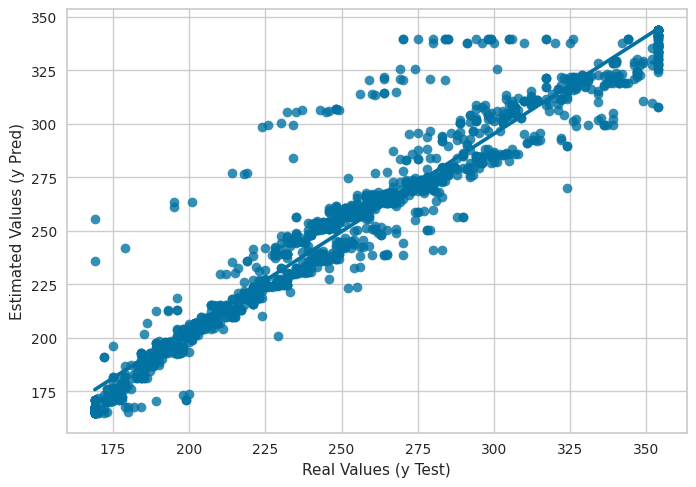

In [67]:
data = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

sns.regplot(data=data, x='y_test', y='y_pred', ci=None)
plt.xlabel('Real Values (y Test)')
plt.ylabel('Estimated Values (y Pred)')
plt.show()

### <font color='#3D8D7A'> <b> Evaluating the Model</b><font color='black'>



#### <font color='#3D8D7A'> <b> Evaluating: Performance- Error Metrics</b><font color='black'>

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# There is no rmse function, calculate manually by taking the mse square root

def train_val(y_train, y_train_pred, y_test, y_pred, i): 
    
    scores = {
    i+"_train": {"R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),                          
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},
    
    i+"_test": {"R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}
    }
    
    return pd.DataFrame(scores)

In [69]:
mlr_score = train_val(y_train, y_train_pred, y_test, y_pred, "multi")
mlr_score

# As can be seen, high R2 scores were obtained with only 4 features. (excluding categorical features)

,multi_train,multi_test
R2,0.917769,0.913095
mae,9.389240,9.596814
mse,224.986651,242.146491
rmse,14.999555,15.561057


# <font color='#3D8D7A'> <b> Cross Validation for Multiple Linear</b><font color='black'>

In [70]:
from sklearn.metrics import get_scorer_names

scorers = get_scorer_names()
print(scorers)

# The metric names that we can use in cross validation and gridsearchCV operations should be written as follows
# otherwise you will get an error.

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'max_error', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples', 'recall_weighted', 'roc_auc', 'roc_auc_ovo', 'roc_auc_ovo_weight

In [71]:
from sklearn.model_selection import cross_validate, cross_val_score

# Both functions cross_validate, cross_val_score can be used for CV operation.
#However, while cross_val_score returns a score for a single metric, cross_validate can return a score for multiple metrics and therefore offers more flexible and wide-ranging usage
# possibilities. For this reason, it is often preferred

**Overfitting Check and Cross Validation**

1. **Overfitting Check**:

- Overfitting is when a machine learning model overfits the training data and performs poorly on new, unseen data.
- Overfitting check is done by comparing the scores on the training set and the validation set. If the scores on the training set are much higher than the validation set, this may be a sign of overfitting.

2. **Resetting the Model Before Each Cross Validation**:
- The model should be reset before each cross validation iteration. Otherwise, information from previous iterations may leak into the new iteration (data leakage) and lead to misleading results.

3. **Using return_train_score=True**:
- In the cross validation process, the return_train_score=True option also returns the scores of the training set for each iteration. This is useful for better understanding overfitting by comparing training and validation scores.

**Negative Scoring Metrics**

- **Maximized Scores**: Scikit-learn algorithms are designed to maximize scores. However, metrics such as MAE (Mean Absolute Error), MSE (Mean Squared Error), and RMSE (Root Mean Squared Error) are actually metrics that need to be minimized.

- **Negative Scoring**: Scikit-learn adapts to the maximizing tendency of the algorithm by shifting these metrics to the negative axis. This should be taken into account when evaluating metrics such as MAE, MSE, and RMSE.

In summary, the use of cross validation and scoring metrics is critical to assessing the generalization ability of the model and detecting overfitting. These techniques are used to more accurately understand the performance of the model on real-world data.

In [72]:
model = LinearRegression()
scores = cross_validate(model, X_train, y_train, 
                        scoring = ['r2', 'neg_mean_absolute_error','neg_mean_squared_error', \
                                    'neg_root_mean_squared_error'], cv = 10, return_train_score=True)

In [73]:
pd.DataFrame(scores, index = range(1,11))

# scores can be seen by typing
# scores are returned in json format.
# to make the json format more readable we put the score data in df

,fit_time,score_time,test_r2,train_r2,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error
1,0.006118,0.003341,0.893681,0.920195,-10.012765,-9.252383,-269.825064,-220.075401,-16.426353,-14.834939
2,0.005100,0.003478,0.936190,0.915690,-8.486359,-9.510372,-176.491754,-230.382438,-13.285020,-15.178354
3,0.004448,0.002693,0.917119,0.917823,-9.976834,-9.342480,-232.881348,-224.132164,-15.260450,-14.971044
4,0.004087,0.002727,0.898233,0.919819,-10.021297,-9.213455,-268.489628,-220.248397,-16.385653,-14.840768
5,0.004146,0.003388,0.927097,0.916758,-8.910098,-9.472454,-194.277992,-228.411489,-13.938364,-15.113288
6,0.004767,0.002746,0.921832,0.917241,-8.894844,-9.496561,-208.905566,-226.803898,-14.453566,-15.060010
7,0.004223,0.002728,0.914767,0.918076,-9.575943,-9.369475,-237.229464,-223.627376,-15.402255,-14.954176
8,0.004675,0.002809,0.915547,0.917959,-9.546391,-9.397527,-229.689205,-224.491663,-15.155501,-14.983046
9,0.004294,0.003044,0.918138,0.917709,-9.777292,-9.388635,-235.338322,-223.870498,-15.340741,-14.962303
10,0.004160,0.002662,0.928348,0.916458,-8.775499,-9.442755,-201.915995,-227.549796,-14.209715,-15.084754


In [74]:
scores = pd.DataFrame(scores, index=range(1,11))
scores.iloc[:, 2:].mean()

test_r2                                0.917095
train_r2                               0.917773
test_neg_mean_absolute_error          -9.397732
train_neg_mean_absolute_error         -9.388610
test_neg_mean_squared_error         -225.504434
train_neg_mean_squared_error        -224.959312
test_neg_root_mean_squared_error     -14.985762
train_neg_root_mean_squared_error    -14.998268
dtype: float64

In [75]:
mlr_score = train_val(y_train, y_train_pred, y_test, y_pred, "m_linear")
mlr_score

# The train and test set scores we get from the train_val function give us insight into whether there is overfitting in our data.
#However, whether there is really overfitting is done by comparing the train and validation scores taken from CV as shown above.

# In addition, we check whether the test scores we will give to the customer are really consistent scores by comparing them with the validation scores we get from CV.
#If the scores are close to each other, we say the scores are consistent, if not, we say the scores are
# inconsistent.

,m_linear_train,m_linear_test
R2,0.917769,0.913095
mae,9.389240,9.596814
mse,224.986651,242.146491
rmse,14.999555,15.561057


In [76]:
pd.concat([slr_score, mlr_score], axis=1)

# We concatenate the scores we got from simple linear and multiple linear models.

,s_linear_train,s_linear_test,m_linear_train,m_linear_test
R2,0.745021,0.753897,0.917769,0.913095
mae,20.774338,20.219191,9.389240,9.596814
mse,699.400297,678.516397,224.986651,242.146491
rmse,26.446177,26.048347,14.999555,15.561057


In [77]:
# Compare errors as percentage of target mean value

print("train RMSE:", 20.762905/df["co2"].mean())
print("CV RMSE:", 20.929894/df["co2"].mean())

train RMSE: 0.08307204773712804
CV RMSE: 0.08374016803048658


In [78]:
mlr.coef_

array([ 6.08606219,  4.14610929,  2.92562982, -4.9223232 ])

In [79]:
mlr_df = pd.DataFrame(mlr.coef_, index=X_train.columns, columns = ["mlr_coef"])
mlr_df

,mlr_coef
engine_size,6.086062
cylinders,4.146109
fuel_cons_comb,2.925630
fuel_cons_comb_mpg,-4.922323


#### <font color='#3D8D7A'> <b> Evaluating: Residuals Distributions</b><font color='black'>

In [80]:
residuals = y_test-y_pred

# In order to check some assumptions that are necessary to understand whether a data is linear reg. 
#appropriate, we first calculate the residuals in the  test data.

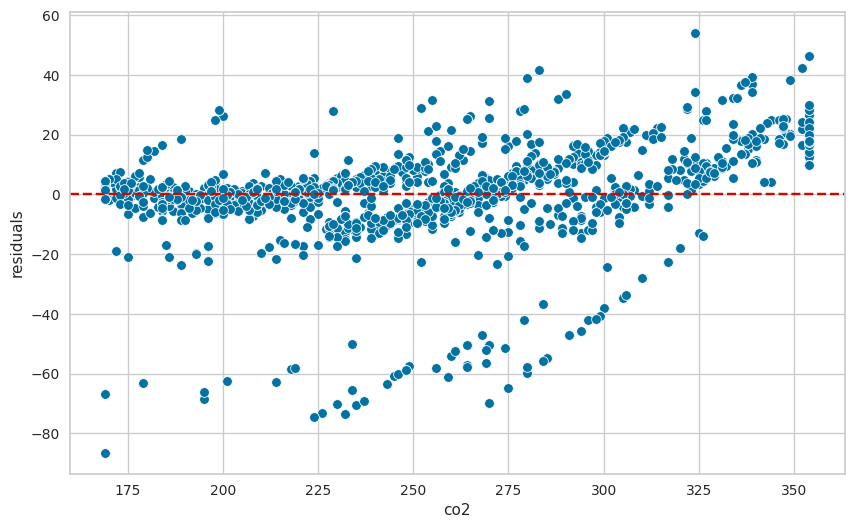

In [81]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = y_test, y = residuals) #-residuals
plt.axhline(y = 0, color ="r", linestyle = "--")
plt.ylabel("residuals");

# If there is a significant correlation between feature and target in simple linear reg., we could say that data is suitable for linear reg.
# However, making an interpretation by looking at the significant correlation between all features and target in multiple lin.reg.
# may mislead us. In these cases, we will look for some assumptions.

# residuals;
# 1- It will be distributed approximately equally and randomly on both sides of the axis where the error is 0
# and it should not contain any patterns
# 2- This distribution will be suitable for normal distribution

# If these conditions are met, we can say that data is suitable for linear reg..

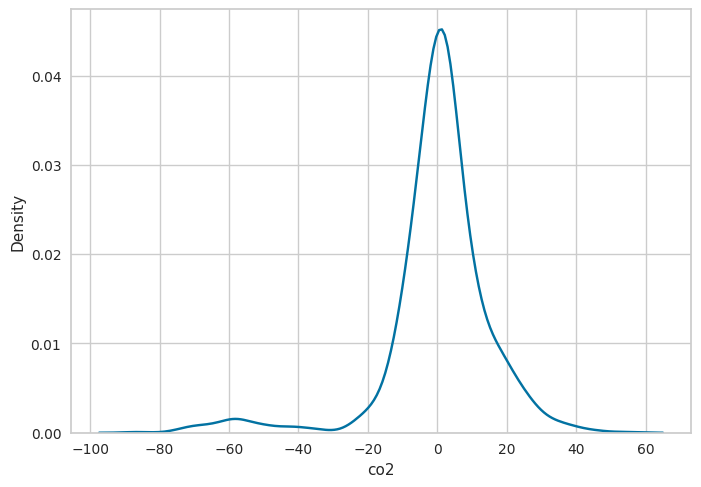

In [82]:
sns.kdeplot(residuals);

# You can check whether the residuals follow a normal distribution via the kdeplot.

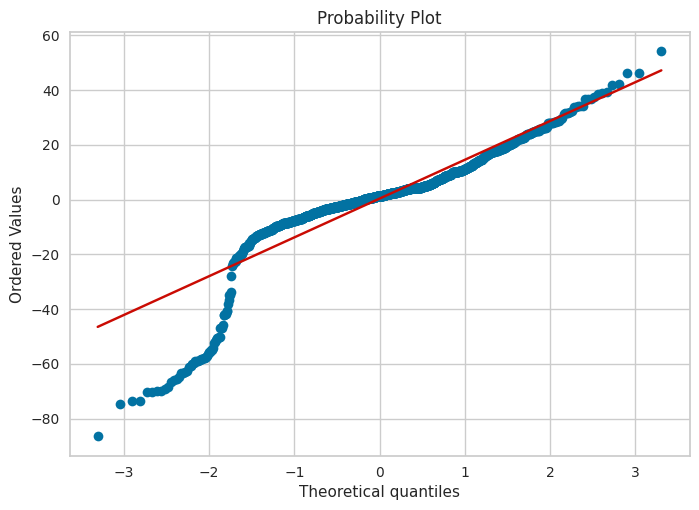

In [83]:
# pip install scipy
import scipy.stats as stats

stats.probplot(residuals, dist ="norm", plot =plt);

#probability plot; is used to check the conformity of the residuals to a normal distribution.
#dist parameter is set to "norm", indicating that a normal distribution will be used as the expected theoretical distribution.
#If the data has a normal distribution, the points on the plot will be distributed approximately along a straight line.
#However, if the data does not follow a normal distribution, the points will be spread outside the line, indicating that the model's errors
#do not follow a normal distribution.

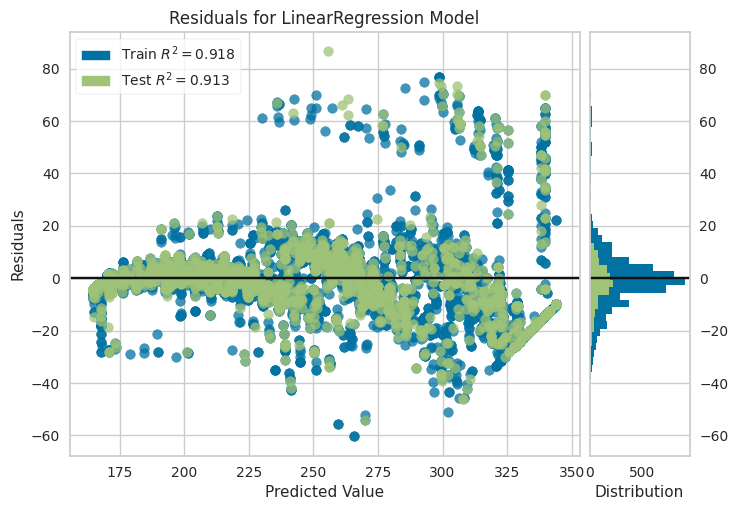

In [84]:
from yellowbrick.regressor import ResidualsPlot


model = LinearRegression()
visualizer = ResidualsPlot(model)

visualizer.fit(X_train, y_train) 
visualizer.score(X_test, y_test)  
visualizer.show();          

In [86]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Bağımlı değişkenin tahminleri
y_pred = model.predict(X_test)

# Breusch-Pagan testi
bp_test = het_breuschpagan(residuals, sm.add_constant(y_pred))
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

#If p-value < 0.05: There is heteroskedasticity, the model should be corrected.
#If p-value > 0.05: There is no heteroskedasticity problem, it can be said that the model meets this assumption.

{'LM Statistic': 136.58613681898154, 'LM-Test p-value': 1.4852875805552658e-31, 'F-Statistic': 150.3002597495447, 'F-Test p-value': 5.6519668632560195e-33}


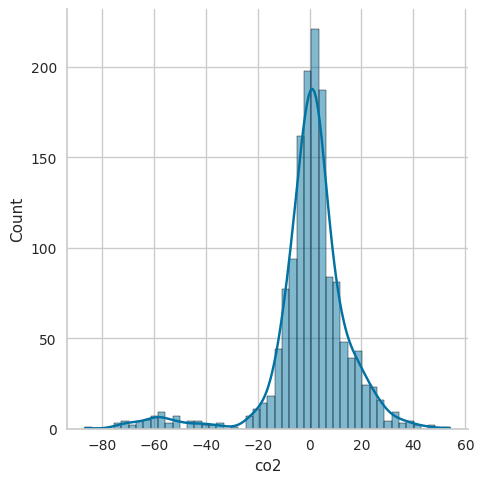

In [87]:
sns.displot((y_test-y_pred), bins=50, kde=True);

#### <font color='#3D8D7A'> <b>Evaluating: Prediction Error for LinearRegression</b><font color='black'>

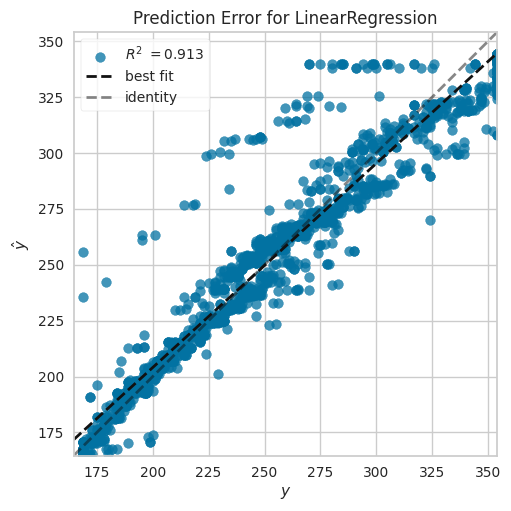

In [88]:
# we look at how our errors are distributed

model = LinearRegression() # we reset our model
visualizer = PredictionError(model)

visualizer.fit(X_train, y_train) # we train with train data
visualizer.score(X_test, y_test) # we get the scores with test data
visualizer.show(); # we draw the graphs

# <font color='green'> <b>Regularization</b><font color='black'>

**"Regularization,"** is a technique that helps reduce or prevent overfitting of a machine learning model. An overfit model is a model that is well-fitted to the training data, but has poor generalization to new and unseen data.

Regularization is used to control the complexity of the model and prevent overfitting. It is usually implemented by changing the source function or cost function of the model. Common techniques include **L1 and L2 regularization**.

L1 regularization reduces the coefficients of the model by making some features unimportant and making the model less complex. L2 regularization reduces the magnitude of the coefficients, reducing overfitting.

Ultimately, when implemented correctly, regularization can reduce overfitting and make the model generalize better. However, which regularization techniques to use and how strongly to apply them depends on the characteristics of your dataset and your model.

In [89]:
df_new = df[['engine_size', 'fuel_cons_city', 'fuel_cons_hwy', 'fuel_cons_comb','co2']]
df_new.head()

,engine_size,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb,co2
0,2.0,9.9,6.7,8.5,196
1,2.4,11.2,7.7,9.6,221
2,1.5,8.0,6.1,7.2,169
3,3.5,12.7,9.1,11.1,255
4,3.5,12.1,8.7,10.6,244


In [90]:
X = df_new[['engine_size', 'fuel_cons_city', 'fuel_cons_hwy', 'fuel_cons_comb']] 
y = df_new['co2'] 

# <font color='#3D8D7A'> <b>Polynomial Features</b><font color='black'>

**Polynomial regression - transformation** is a modeling technique with very limited use. It is especially useful for modeling complex and nonlinear relationships between data. For example, it is successfully applied with real data in many fields such as physics, economics and engineering. However, polynomial regression is also generally used in academic research and hypothesis testing.

Polynomial regression adds extra features to the data by creating new features using existing features. This helps the model to fit the data better, while at the same time increasing the complexity of the model.

Polynomial regression can be useful especially when the number of features is low, i.e. when there are a limited number of features in the data. Therefore, it offers a flexible modeling option according to the number of features in your data set.

The polynomial degree determines how well the model can capture nonlinear relationships. As the degree increases, the model can model more complex relationships, but this can also increase the risk of overfitting. Therefore, careful selection of the polynomial degree is important to create a successful model.

In [91]:
from sklearn.preprocessing import PolynomialFeatures

# To generate poly features, we import the PolynomialFeatures function.


In [92]:
polynomial_converter = PolynomialFeatures(degree=4, include_bias=False)

# We write the degree we want into the function.
# Since our intercept value is our bias in linear regression, we do not need to add a bias separately
# We make the include_bias parameter False.
# Even if include_bias=True, our results do not change much, but it is not preferred

In [93]:
poly_features = polynomial_converter.fit_transform(X)

In [94]:
poly_features.shape

# Feature 4 increased to 69 with Polynomial Conversion

(7385, 69)

In [95]:
feature_names = polynomial_converter.get_feature_names_out(X.columns)
feature_names

array(['engine_size', 'fuel_cons_city', 'fuel_cons_hwy', 'fuel_cons_comb',
       'engine_size^2', 'engine_size fuel_cons_city',
       'engine_size fuel_cons_hwy', 'engine_size fuel_cons_comb',
       'fuel_cons_city^2', 'fuel_cons_city fuel_cons_hwy',
       'fuel_cons_city fuel_cons_comb', 'fuel_cons_hwy^2',
       'fuel_cons_hwy fuel_cons_comb', 'fuel_cons_comb^2',
       'engine_size^3', 'engine_size^2 fuel_cons_city',
       'engine_size^2 fuel_cons_hwy', 'engine_size^2 fuel_cons_comb',
       'engine_size fuel_cons_city^2',
       'engine_size fuel_cons_city fuel_cons_hwy',
       'engine_size fuel_cons_city fuel_cons_comb',
       'engine_size fuel_cons_hwy^2',
       'engine_size fuel_cons_hwy fuel_cons_comb',
       'engine_size fuel_cons_comb^2', 'fuel_cons_city^3',
       'fuel_cons_city^2 fuel_cons_hwy',
       'fuel_cons_city^2 fuel_cons_comb',
       'fuel_cons_city fuel_cons_hwy^2',
       'fuel_cons_city fuel_cons_hwy fuel_cons_comb',
       'fuel_cons_city fuel_cons_c

In [96]:
poly_df = pd.DataFrame(poly_features, columns=feature_names)
poly_df.head()

,engine_size,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb,engine_size^2,engine_size fuel_cons_city,engine_size fuel_cons_hwy,engine_size fuel_cons_comb,fuel_cons_city^2,fuel_cons_city fuel_cons_hwy,...,fuel_cons_city^2 fuel_cons_comb^2,fuel_cons_city fuel_cons_hwy^3,fuel_cons_city fuel_cons_hwy^2 fuel_cons_comb,fuel_cons_city fuel_cons_hwy fuel_cons_comb^2,fuel_cons_city fuel_cons_comb^3,fuel_cons_hwy^4,fuel_cons_hwy^3 fuel_cons_comb,fuel_cons_hwy^2 fuel_cons_comb^2,fuel_cons_hwy fuel_cons_comb^3,fuel_cons_comb^4
0,2.0,9.9,6.7,8.5,4.00,19.80,13.40,17.00,98.01,66.33,...,7081.2225,2977.5537,3777.4935,4792.3425,6079.8375,2015.1121,2556.4855,3243.3025,4114.6375,5220.0625
1,2.4,11.2,7.7,9.6,5.76,26.88,18.48,23.04,125.44,86.24,...,11560.5504,5113.1696,6374.8608,7947.8784,9909.0432,3515.3041,4382.7168,5464.1664,6812.4672,8493.4656
2,1.5,8.0,6.1,7.2,2.25,12.00,9.15,10.80,64.00,48.80,...,3317.7600,1815.8480,2143.2960,2529.7920,2985.9840,1384.5841,1634.2632,1928.9664,2276.8128,2687.3856
3,3.5,12.7,9.1,11.1,12.25,44.45,31.85,38.85,161.29,115.57,...,19872.5409,9570.3517,11673.7257,14239.3797,17368.9137,6857.4961,8364.6381,10203.0201,12445.4421,15180.7041
4,3.5,12.1,8.7,10.6,12.25,42.35,30.45,37.10,146.41,105.27,...,16450.6276,7967.8863,9707.9994,11828.1372,14411.2936,5728.9761,6980.1318,8504.5284,10361.8392,12624.7696


In [97]:
def color_correlation2(val):
    """
    Takes a scalar and returns a string with
    the css property in a variety of color scales 
    for different correlations.
    """
    if val >= 0.9 and val < 0.99999 or val <= -0.9 and val > -0.99999:
        color = 'red'
    elif val < 0.9 and val >= 0.3 or val > -0.9 and val <= -0.3:
        color = 'blue'
    elif val == 1:
        color = 'green'    
    else:
        color = 'black'
    return 'color: %s' % color
 
poly_df.corr().style.applymap(color_correlation2)

# We use the feature to display values ​​greater than the correlation between them -0.90, +0.90 in the color we want.

# The multicolineracy problem occurs as a problem in gradient descent-based models such as linear and logistic reg. 
#The scores we obtain in data with a multicolineracy problem will not be different. However, if we are going to do a feature selection
# we definitely need to fix this problem. Regulirazition algorithms fix the overfitting problem as well as the
# multicolineracy problem.

,engine_size,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb,engine_size^2,engine_size fuel_cons_city,engine_size fuel_cons_hwy,engine_size fuel_cons_comb,fuel_cons_city^2,fuel_cons_city fuel_cons_hwy,fuel_cons_city fuel_cons_comb,fuel_cons_hwy^2,fuel_cons_hwy fuel_cons_comb,fuel_cons_comb^2,engine_size^3,engine_size^2 fuel_cons_city,engine_size^2 fuel_cons_hwy,engine_size^2 fuel_cons_comb,engine_size fuel_cons_city^2,engine_size fuel_cons_city fuel_cons_hwy,engine_size fuel_cons_city fuel_cons_comb,engine_size fuel_cons_hwy^2,engine_size fuel_cons_hwy fuel_cons_comb,engine_size fuel_cons_comb^2,fuel_cons_city^3,fuel_cons_city^2 fuel_cons_hwy,fuel_cons_city^2 fuel_cons_comb,fuel_cons_city fuel_cons_hwy^2,fuel_cons_city fuel_cons_hwy fuel_cons_comb,fuel_cons_city fuel_cons_comb^2,fuel_cons_hwy^3,fuel_cons_hwy^2 fuel_cons_comb,fuel_cons_hwy fuel_cons_comb^2,fuel_cons_comb^3,engine_size^4,engine_size^3 fuel_cons_city,engine_size^3 fuel_cons_hwy,engine_size^3 fuel_cons_comb,engine_size^2 fuel_cons_city^2,engine_size^2 fuel_cons_city fuel_cons_hwy,engine_size^2 fuel_cons_city fuel_cons_comb,engine_size^2 fuel_cons_hwy^2,engine_size^2 fuel_cons_hwy fuel_cons_comb,engine_size^2 fuel_cons_comb^2,engine_size fuel_cons_city^3,engine_size fuel_cons_city^2 fuel_cons_hwy,engine_size fuel_cons_city^2 fuel_cons_comb,engine_size fuel_cons_city fuel_cons_hwy^2,engine_size fuel_cons_city fuel_cons_hwy fuel_cons_comb,engine_size fuel_cons_city fuel_cons_comb^2,engine_size fuel_cons_hwy^3,engine_size fuel_cons_hwy^2 fuel_cons_comb,engine_size fuel_cons_hwy fuel_cons_comb^2,engine_size fuel_cons_comb^3,fuel_cons_city^4,fuel_cons_city^3 fuel_cons_hwy,fuel_cons_city^3 fuel_cons_comb,fuel_cons_city^2 fuel_cons_hwy^2,fuel_cons_city^2 fuel_cons_hwy fuel_cons_comb,fuel_cons_city^2 fuel_cons_comb^2,fuel_cons_city fuel_cons_hwy^3,fuel_cons_city fuel_cons_hwy^2 fuel_cons_comb,fuel_cons_city fuel_cons_hwy fuel_cons_comb^2,fuel_cons_city fuel_cons_comb^3,fuel_cons_hwy^4,fuel_cons_hwy^3 fuel_cons_comb,fuel_cons_hwy^2 fuel_cons_comb^2,fuel_cons_hwy fuel_cons_comb^3,fuel_cons_comb^4
engine_size,1.000000,0.856402,0.792870,0.844440,0.984355,0.973810,0.969307,0.973582,0.849134,0.828495,0.843938,0.783049,0.815040,0.835871,0.948629,0.959031,0.960525,0.959989,0.932264,0.930398,0.932042,0.919477,0.927091,0.930669,0.827951,0.817115,0.824881,0.796090,0.810571,0.820531,0.763155,0.785421,0.802506,0.814807,0.907425,0.923150,0.926830,0.924615,0.921074,0.923295,0.921888,0.920015,0.922206,0.921964,0.887453,0.886687,0.887241,0.880416,0.884580,0.886290,0.868199,0.876248,0.881675,0.884577,0.797695,0.791237,0.795733,0.779282,0.787382,0.793040,0.761274,0.773326,0.782722,0.789587,0.736456,0.752932,0.766460,0.777214,0.785338
fuel_cons_city,0.856402,1.000000,0.948832,0.993935,0.826521,0.928082,0.921584,0.927450,0.992191,0.981714,0.990849,0.941559,0.970609,0.986146,0.782288,0.860447,0.860408,0.861173,0.934282,0.934623,0.935048,0.924741,0.931910,0.934533,0.971318,0.968569,0.971163,0.953586,0.964272,0.969490,0.923834,0.944215,0.958118,0.966172,0.736805,0.800072,0.802803,0.801526,0.863250,0.866312,0.864622,0.863324,0.865589,0.865197,0.918269,0.920915,0.919390,0.917230,0.919856,0.919674,0.906563,0.913754,0.917875,0.919087,0.942069,0.942254,0.942426,0.935741,0.940314,0.941902,0.921678,0.931192,0.937379,0.940450,0.898924,0.914102,0.925497,0.933392,0.938023
fuel_cons_hwy,0.792870,0.948832,1.000000,0.976917,0.759652,0.864936,0.896142,0.877438,0.941461,0.978732,0.956677,0.993657,0.987074,0.969639,0.713698,0.794212,0.817521,0.803180,0.873544,0.900732,0.883776,0.920617,0.908564,0.893129,0.921736,0.949773,0.932421,0.968968,0.957586,0.942062,0.976335,0.972863,0.963988,0.950525,0.667385,0.732597,0.752619,0.740184,0.799342,0.821226,0.807395,0.838515,0.827722,0.814854,0.860406,0.883746,0.868868,0.902382,0.890628,0.876717,0.915617,0.907435,0.896808,0.883917,0.894120,0.916817,0.902454,0.934595,0.923513,0.910152,0.946543,0.939332,0.929459,0.917168,0.951368,0.948863,0.943156,0.934592,0.923450
fuel_cons_comb,

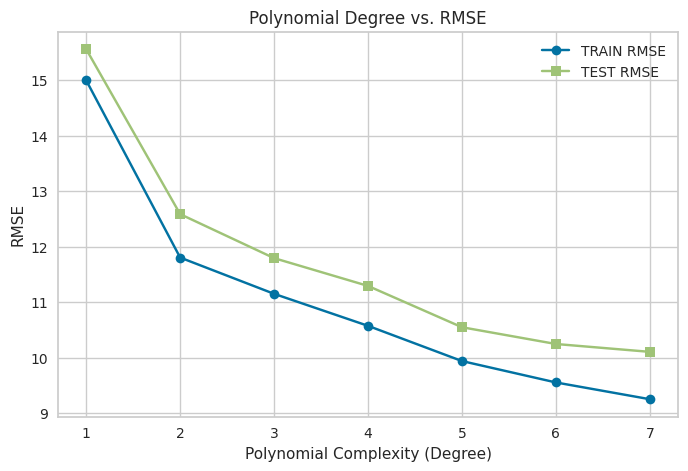

In [98]:


train_rmse_errors = []
test_rmse_errors = []

# 1'den 8'a kadar polinom derecelerini dene
degrees = range(1,8)

for degree in degrees:
    poly_converter = PolynomialFeatures(degree=degree, include_bias=False)
    
    X_train_poly = poly_converter.fit_transform(X_train)
    X_test_poly = poly_converter.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)

# Grafik çizme
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_rmse_errors, label="TRAIN RMSE", marker='o')
plt.plot(degrees, test_rmse_errors, label="TEST RMSE", marker='s')
plt.xlabel("Polynomial Complexity (Degree)")
plt.ylabel("RMSE")
plt.title("Polynomial Degree vs. RMSE")
plt.legend()
plt.show()


#### According to the graph, the most suitable polynomial degree is the point where the test RMSE is at its lowest and the difference between train RMSE and test RMSE is not too big.

**Analysis:**
**Degree 1-3:** Both train and test RMSE are high. The model is underfitting.

**Degree 4-5:** Test RMSE is decreasing and the difference between train RMSE and train RMSE is at a reasonable level. It may be a good balance point.

**Degree 6-7:** Train RMSE continues to decrease, but test RMSE improves very little and the difference starts to widen. There is a risk of overfitting.
**🔹 Result:** Degree 4 or 5 may be the most suitable. Because:

Train and test RMSE values ​​are close to the lowest level.
The difference between train and test errors is not too wide (no overfitting).

### <font color='#3D8D7A'> <b>Poly(degree=4)</b><font color='black'>

In [99]:
# Selected degree=4

poly_converter = PolynomialFeatures(degree =4, include_bias=False)

#### <font color='#3D8D7A'> <b>Model</b><font color='black'> 

In [102]:
# Poly linear model

poly_lin_reg = LinearRegression()

#### <font color='#3D8D7A'> <b>Train | Test Split</b><font color='black'>


In [100]:
X_train, X_test, y_train, y_test = train_test_split(poly_converter.fit_transform(X), y,
                                                    test_size = 0.2, random_state = 42)

#### <font color='#3D8D7A'> <b>Training the Model</b><font color='black'>

In [103]:
poly_lin_reg.fit(X_train, y_train)

LinearRegression()

#### <font color='#3D8D7A'> <b>Predicting Test Data</b><font color='black'>

In [104]:
y_train_pred = poly_lin_reg.predict(X_train)
y_pred = poly_lin_reg.predict(X_test)

#### <font color='#3D8D7A'> <b>Evaluating the Model</b><font color='black'>

In [105]:
poly_mlr_score = train_val(y_train, y_train_pred, y_test, y_pred, "poly(4)")
poly_mlr_score

,poly(4)_train,poly(4)_test
R2,0.954769,0.943900
mae,5.612592,6.198643
mse,124.067854,154.669477
rmse,11.138575,12.436618


#### <font color='#3D8D7A'> <b>Comparison of Multiple Linear & Poly Multiple Linear Regression</b><font color='black'> 

In [106]:
result = pd.concat([mlr_score, poly_mlr_score], axis=1)
result

,m_linear_train,m_linear_test,poly(4)_train,poly(4)_test
R2,0.917769,0.913095,0.954769,0.943900
mae,9.389240,9.596814,5.612592,6.198643
mse,224.986651,242.146491,124.067854,154.669477
rmse,14.999555,15.561057,11.138575,12.436618


- The polynomial regression model (degree 4) performs better than the multiple linear regression model, achieving higher \( R^2 \) values 
- and lower MAE, MSE, and RMSE on both training and test sets, indicating better overall performance and accuracy.

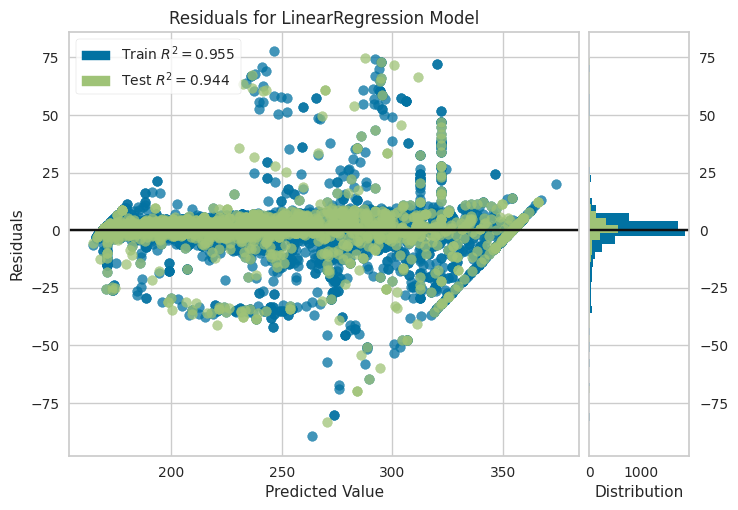

In [107]:
# Distributions of Poly_Multi Regression Residuals

poly_lin_reg = LinearRegression()
visualizer = ResidualsPlot(poly_lin_reg)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show();

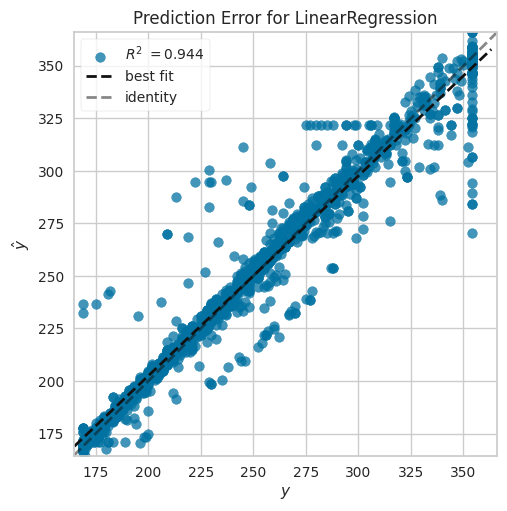

In [108]:
# Prediction Error for Poly_Multi LinearRegression

poly_lin_reg = LinearRegression()
visualizer = PredictionError(poly_lin_reg)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show();

# <font color='#3D8D7A'> <b>Scaling the Data</b><font color='black'> 

**Why Do We Scaling?**

1. **Standardization**: It allows algorithms to work more efficiently by bringing features at different scales into a similar range.

2. **Distance-Based Algorithms**: Distance-based algorithms such as KNN or K-means can be affected by unscaled data when calculating the distance between features. Scaling helps such algorithms produce fairer and more consistent results.

3. **Coefficient Comparison**: In models such as linear regression, scaling is important to compare the coefficients of features.

**Most Commonly Used Scaling Algorithms**

1. **StandardScaler (Z-Score Normalization)**: Scales each feature so that the mean is 0 and the standard deviation is 1.

2. **MinMaxScaler (Normalization)**: Scales all features within a certain range (usually between 0 and 1).

3. **RobustScaler**: It is a scaling method that is less affected by outliers. It uses the median and the interval between the quartiles.

**Which Scaling Algorithm Should I Use?**

- **Standard Application**: StandardScaler and MinMaxScaler are usually tried first. The algorithm that gives the best results is preferred.

- **Outlier Case**: If there are outliers in the data set, RobustScaler can be preferred. However, it is best to continue with the algorithm that gives the best results by trying all scaling algorithms.

In summary, scaling allows machine learning algorithms to work more effectively and accurately by bringing different features to a similar range. Which scaling method to use may vary depending on the characteristics of the data set and the type of model. Therefore, it is important to determine which one provides the best performance by trying different scaling methods.

In [110]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# StandardScaler

scaler = StandardScaler()

**Scaling Process**

1. **fit() Method**:
- scaler.fit(X_train): This step means that the selected scaling algorithm (e.g. StandardScaler, MinMaxScaler, RobustScaler etc.) analyzes the distribution of features in the training dataset and calculates the necessary parameters for scaling (e.g. mean, standard deviation).

- This process creates scaling formulas and is done only on the training set.

2. **transform() Method**:
- scaler.transform(): This step scales both the training set and the test set using the parameters previously calculated with the fit method.

- Scaling is the process of transforming the data with the specified formula.

**Applying Scaling to Training and Test Sets**

- **Applying fit() Only on the Training Set**: Scaling parameters should be calculated only from the training set. This is because when testing the model on real-world data, the test data must be “unseen” by the model before.

- **Test Set Transformation**: The test set is transformed using the scaling parameters obtained from the training set. This ensures that the training and test sets are scaled the same, allowing for an accurate assessment of the model’s performance.

**Summary**

The scaling process is important for better model performance and fair evaluation. Calculating the scaling parameters only from the training set and applying them to both the training and test sets increases the generalizability and accuracy of the model. Applying the wrong scaling can cause the model to produce misleading results.

In [111]:
scaler.fit(X_train)

#scaler.fit_transform(X_train) 

StandardScaler()

In [112]:
X_train_scaled = scaler.transform(X_train)
X_train_scaled 
# We perform scaling operation on the train set using the mean and std information of the train set.

array([[-0.11750317, -0.36245497, -0.456766  , ..., -0.53665637,
        -0.5307447 , -0.52489541],
       [ 0.6460348 ,  0.70295837,  0.67854117, ...,  0.3607965 ,
         0.35591607,  0.34713888],
       [-0.11750317,  0.4123911 ,  0.00767784, ..., -0.14529832,
        -0.09172518, -0.03952438],
       ...,
       [ 0.26426582, -0.26559921, -0.0955319 , ..., -0.37318844,
        -0.39415962, -0.41368227],
       [-0.49927216, -0.97587477, -0.8180001 , ..., -0.73666767,
        -0.74188676, -0.74469776],
       [ 0.6460348 ,  0.28325009,  0.57533143, ...,  0.13681854,
         0.08278097,  0.03033613]])

In [113]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled 
# We perform scaling operation on the test set using the mean and std information of the train set..

array([[-0.11750317, -0.03960244,  0.00767784, ..., -0.26835084,
        -0.27652299, -0.28521792],
       [ 0.95144999,  1.54237495,  1.3494045 , ...,  1.36622066,
         1.41070775,  1.44620548],
       [ 2.17311075,  1.15495191,  1.24619476, ...,  1.06331908,
         1.0379272 ,  1.00622178],
       ...,
       [-1.26281013, -1.20187154, -1.23083908, ..., -0.85429044,
        -0.84735514, -0.8386892 ],
       [ 0.26426582, -0.20102871, -0.40516113, ..., -0.48916447,
        -0.47432038, -0.46014526],
       [-0.88104114, -0.94358952, -1.23083908, ..., -0.8308657 ,
        -0.8134004 , -0.79512539]])

In [114]:
pd.DataFrame(X_train_scaled).agg(['mean','std']).round(2)

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
mean,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [115]:
pd.DataFrame(X_test_scaled).agg(['mean','std']).round(2) 

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
mean,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,...,-0.01,-0.01,-0.01,-0.01,-0.01,-0.00,-0.01,-0.01,-0.01,-0.01
std,0.99,1.00,1.02,1.01,0.99,0.99,1.01,1.00,1.00,1.01,...,1.01,1.02,1.02,1.02,1.01,1.03,1.02,1.02,1.02,1.02


# <font color='#3D8D7A'> <b>Ridge Regression</b><font color='black'>

**Why and When to Use Ridge-Lasso**

Ridge and Lasso regressions are regularized versions of linear regression. This regularization makes the model more resistant to overfitting and can sometimes improve the overall performance of the model.

1. **Overfitting Prevention**:
- **Ridge (L2 Regularization)**: Adds the sum of the squares of the coefficients as a penalty to shrink the model's coefficients. This reduces the model's complexity and prevents overfitting.
- **Lasso (L1 Regularization)**: Adds the sum of the absolute values ​​of the coefficients as a penalty to compress the model's coefficients towards zero. This performs feature selection by making some coefficients all zero and reduces the model's complexity.

2. **Feature Selection**:
- Lasso regression can remove ineffective features from the model by making some coefficients all zero. This is also called feature selection and is very useful in high dimensional datasets.

3. **Multicollinarity**:

- If there is a high correlation (multicollinarity) between the features in a dataset, this can destabilize the coefficients of linear regression. Ridge and Lasso can stabilize the coefficients in such cases.

4. **Model Interpretability**:

- Lasso can increase the interpretability of the model by including only the most important features in the model. Ridge also makes the effect of the features in the model more understandable by reducing the coefficients.

As a result, Ridge and Lasso regressions can help us overcome some of the limitations of linear regression and create more generalizable, more stable models. Which method to use depends on the dataset, the problem definition and especially how flexible you want the model to be. There are also approaches like **Elastic Net** to find a balance between these two Regularization techniques.

**L2 Regularization (Ridge Regularization):**

- L2 regularization aims to keep the model weights low, thus limiting the robustness of the model.

- It shrinks the coefficients towards zero, but does not set any coefficient exactly to zero. It is used in cases where we want all the features to remain.

- Error is added to the sum of the residuals as lambda (regularization parameter) x sum of the squares of the coefficients.

In [117]:
# Set the Ridge Regression Model

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1, random_state=42) # default alpha=1

# alpha reg. is the hyper parameter. As this value increases, the applied reg. force increases. To overcome overfitting
# this hyper parameter should be increased

In [119]:
# Fit the model

ridge_model.fit(X_train_scaled, y_train) 

# The data we will train on in the ridge reg. algorithm must be scaled.
#This process eliminates the multicolinarity problem by giving equal weights to all features by the model and can group the features as important and unimportant.

Ridge(alpha=1, random_state=42)

In [120]:
# Prediction

y_pred = ridge_model.predict(X_test_scaled)        
y_train_pred = ridge_model.predict(X_train_scaled)

In [121]:
ridge_score = train_val(y_train, y_train_pred, y_test, y_pred, "ridge") 
ridge_score

,ridge_train,ridge_test
R2,0.948284,0.936518
mae,5.920057,6.464808
mse,141.854064,175.021737
rmse,11.910250,13.229578


In [122]:
ridge_model.coef_[:20]

array([  2.47418381,   6.69275033, -10.20839688,   2.71897925,
       -29.08134856,   5.25113137,   1.13186166,   3.17445809,
        11.63458476,   6.49318926,  12.81891681,   5.38142596,
         9.17185864,  15.23936483, -24.09934814,  -6.96654478,
       -12.54602091, -11.30354239,  23.62796988,  12.56567976])

In [123]:
result = pd.concat([result, ridge_score], axis=1)
result

,m_linear_train,m_linear_test,poly(4)_train,poly(4)_test,ridge_train,ridge_test
R2,0.917769,0.913095,0.954769,0.943900,0.948284,0.936518
mae,9.389240,9.596814,5.612592,6.198643,5.920057,6.464808
mse,224.986651,242.146491,124.067854,154.669477,141.854064,175.021737
rmse,14.999555,15.561057,11.138575,12.436618,11.910250,13.229578


#### Cross Validation for Ridge with Alpha=1 

In [124]:
model = Ridge(alpha=1)
scores = cross_validate(model, X_train_scaled, y_train,
                    scoring=['r2', 'neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'], 
                        cv=10, return_train_score=True)

# We get our scores from CV according to our default alpha value. 
# The reason for neg=negative is; normally it tries to maximize the values, so it does not maximize the errors.

In [125]:
scores = pd.DataFrame(scores, index = range(1, 11))
scores.iloc[:,2:].mean()

# we see that the train and validation set scores are close to each other and we are now convinced that there is no overfitting

test_r2                                0.947579
train_r2                               0.948286
test_neg_mean_absolute_error          -5.943169
train_neg_mean_absolute_error         -5.920397
test_neg_mean_squared_error         -143.248856
train_neg_mean_squared_error        -141.842622
test_neg_root_mean_squared_error     -11.944574
train_neg_root_mean_squared_error    -11.909440
dtype: float64

In [126]:
ridgeCV_score = train_val(y_train, y_train_pred, y_test, y_pred, "ridgeCV")
ridgeCV_score

,ridgeCV_train,ridgeCV_test
R2,0.948284,0.936518
mae,5.920057,6.464808
mse,141.854064,175.021737
rmse,11.910250,13.229578


In [127]:
rm = Ridge(alpha=1).fit(X_train_scaled, y_train)  # 'GridSearchCV' object has no attribute 'coef_'
rm.coef_

array([  2.47418381,   6.69275033, -10.20839688,   2.71897925,
       -29.08134856,   5.25113137,   1.13186166,   3.17445809,
        11.63458476,   6.49318926,  12.81891681,   5.38142596,
         9.17185864,  15.23936483, -24.09934814,  -6.96654478,
       -12.54602091, -11.30354239,  23.62796988,  12.56567976,
        20.18615454,  12.73829705,  13.22087581,  18.58324802,
         6.80390026,  -0.99019639,   8.12999769,   4.40932835,
         4.69920214,  11.49803382,  15.06523176,  11.65896205,
        11.44092692,  16.57157203,  17.67829528,   6.76128131,
         0.12664752,   0.55208163,   9.47688599,  -4.81576022,
         2.79620123,  -7.68372813,  -7.16575247,  -2.09321375,
        14.12103089,  -2.86591526,   9.47599521,  -4.69759989,
        -2.09290915,   7.1097645 ,   4.89395644,   0.12165074,
         0.47225022,   6.86069676, -15.3177346 , -30.8806255 ,
       -15.81478554, -27.42790152, -25.01521872, -13.62564324,
       -10.56386978, -17.24913178, -17.19886221,  -9.00

In [128]:
rm_df = pd.DataFrame(ridge_model.coef_,  columns = ["ridge_coef_1"])
rm_df

,ridge_coef_1
0,2.474184
1,6.692750
2,-10.208397
3,2.718979
4,-29.081349
...,...
64,12.744493
65,1.400291
66,-6.033205
67,-7.750587


# <font color='#3D8D7A'> <b>GridSearchCV for Ridge; Choosing best alpha value</b><font color='black'>

**Purpose of GridSearchCV**

- **Hyperparameter Optimization**: GridSearchCV is used to find the best combinations of hyperparameters to maximize the performance of the machine learning model.

- **Exhaustive Search**: When there are multiple hyperparameters, GridSearchCV tries all possible combinations of hyperparameters to find the combination that gives the best result.

**Hyperparameter vs. Parameter**

- **Hyperparameter**: Parameters that are set before the model is trained and control the learning process and structure of the model. For example, tree depth in a tree-based model or regularization value in a linear model.

- **Parameter**: Values ​​that the model learns during the training process and extracts from the dataset. For example, coefficients and intercept in a linear regression model.

**How ​​GridSearchCV Works**

1. **Parameter Grid Defining**: A list of various hyperparameters specified by the user and the values ​​to be tried for these parameters (parameter grid) is created.

2. **Search and Evaluation**: GridSearchCV trains the model by trying each combination in this parameter grid and evaluates the performance of the model using cross validation for each combination.

3. **Finding the Best Combination**: Among all the combinations, the hyperparameter combination that maximizes the performance of the model is selected.

4. **Training the Final Model**: The final model is trained with the best hyperparameters selected. Therefore, at the end of GridSearchCV, the model is trained with these best hyperparameters.

**Summary**

GridSearchCV is a hyperparameter optimization tool used to maximize the performance of a machine learning model. It systematically tries all possible hyperparameter combinations to determine the one that gives the best results and trains the final model with that combination. This process is critical to ensuring the model makes more efficient and accurate predictions.

In [129]:
from sklearn.model_selection import GridSearchCV

In [130]:
alpha_space = np.linspace(0.01, 1, 50)
alpha_space 

# The GridsearchCV(GS) algorithm first requires a space range for the relevant hyperparameter (HP).
#For this, we determine the space range that we will give to GS.
#(We give 100 different values ​​divided into equal intervals between 0.01 and 1)

array([0.01      , 0.03020408, 0.05040816, 0.07061224, 0.09081633,
       0.11102041, 0.13122449, 0.15142857, 0.17163265, 0.19183673,
       0.21204082, 0.2322449 , 0.25244898, 0.27265306, 0.29285714,
       0.31306122, 0.33326531, 0.35346939, 0.37367347, 0.39387755,
       0.41408163, 0.43428571, 0.4544898 , 0.47469388, 0.49489796,
       0.51510204, 0.53530612, 0.5555102 , 0.57571429, 0.59591837,
       0.61612245, 0.63632653, 0.65653061, 0.67673469, 0.69693878,
       0.71714286, 0.73734694, 0.75755102, 0.7777551 , 0.79795918,
       0.81816327, 0.83836735, 0.85857143, 0.87877551, 0.89897959,
       0.91918367, 0.93938776, 0.95959184, 0.97979592, 1.        ])

In [131]:
ridge_model = Ridge()

# GridsearchCV also requires the ML algorithm we will use.

In [132]:
param_grid = {"alpha":alpha_space}

# We write hyperparameter spaces into a dictionary with the hyperparameter (HP) names used in the ML algorithm.
# We define the space as a list or array against HP.
# Note that the alpha_space variable we defined against alpha is an array with 100 elements.

In [133]:
grid_ridge = GridSearchCV(estimator=ridge_model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          verbose=1,
                          return_train_score=True)

# We write the relevant metric against scoring according to which metric we want the scores of the ridge ML model to be improved.
# We can write a single metric. The default value is R2_score.

# GridsearcCV takes scores from different regions of the data separately for all values 
#​​in the hyperparameter space in a way that will maximize the metric we want (according to the number we specify in cv) and calculates their average.
# It returns the hyperparameter value/values ​​with the highest average.

# The default cv number is 5.

# Since GrdiseachCV also performs Cross Validation, we specify return_train_score=True in order to obtain validation and train set scores. 
#(It only returns the metric score we wrote against scoring)

In [134]:
grid_ridge.fit(X_train_scaled, y_train)

# Since we give cv = 10, we train in 10 different regions of the data for each alpha value.

Fitting 10 folds for each of 50 candidates, totalling 500 fits


GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': array([0.01      , 0.03020408, 0.05040816, 0.07061224, 0.09081633,
       0.11102041, 0.13122449, 0.15142857, 0.17163265, 0.19183673,
       0.21204082, 0.2322449 , 0.25244898, 0.27265306, 0.29285714,
       0.31306122, 0.33326531, 0.35346939, 0.37367347, 0.39387755,
       0.41408163, 0.43428571, 0.4544898 , 0.47469388, 0.49489796,
       0.51510204, 0.53530612, 0.5555102 , 0.57571429, 0.59591837,
       0.61612245, 0.63632653, 0.65653061, 0.67673469, 0.69693878,
       0.71714286, 0.73734694, 0.75755102, 0.7777551 , 0.79795918,
       0.81816327, 0.83836735, 0.85857143, 0.87877551, 0.89897959,
       0.91918367, 0.93938776, 0.95959184, 0.97979592, 1.        ])},
             return_train_score=True, scoring='neg_root_mean_squared_error',
             verbose=1)

In [135]:
grid_ridge.best_params_

# After training, found 0.01 as the best value.

{'alpha': 0.01}

In [136]:
grid_ridge.best_index_
# returns the df index from which the best score was obtained.

0

In [137]:
pd.DataFrame(grid_ridge.cv_results_).loc[0, ["mean_test_score", "mean_train_score"]]

# Overfitting,
# underfitting evaluation is performed by comparing the "mean_test_score" and "mean_train_score" from the best index of the relevant df.

# Since GridsearchCV also performs Cross validation, we do not need to do extra cross validation.

# The scores we get here are the scores of the scoring metric we give to gridsearchcv.

mean_test_score    -11.778497
mean_train_score   -11.702312
Name: 0, dtype: object

In [138]:
grid_ridge.best_score_

# this code only returns the score of the validation set..

-11.778496573529347

In [139]:
y_pred = grid_ridge.predict(X_test_scaled)
y_train_pred = grid_ridge.predict(X_train_scaled)

# After GiridsearchCv, the grid_ridge model we obtained has the best hyperparameter information.
# And returns the scores according to this hyperparameter. As you can see, grid_ridge can be used as an ML algorithm

In [140]:
ridgeGrid_score = train_val(y_train, y_train_pred, y_test, y_pred, "ridgeGrid")
ridgeGrid_score

# Our scores got even better with the best alpha value.

,ridgeGrid_train,ridgeGrid_test
R2,0.950098,0.939836
mae,5.713213,6.236599
mse,136.880168,165.875137
rmse,11.699580,12.879252


In [141]:
pd.concat([ridge_score, ridgeGrid_score], axis=1)

,ridge_train,ridge_test,ridgeGrid_train,ridgeGrid_test
R2,0.948284,0.936518,0.950098,0.939836
mae,5.920057,6.464808,5.713213,6.236599
mse,141.854064,175.021737,136.880168,165.875137
rmse,11.910250,13.229578,11.699580,12.879252


In [142]:
rgm = Ridge(alpha=0.01).fit(X_train_scaled, y_train) 
rgm.coef_

# Since grid models do not have a coef_ feature, we manually rebuild and train the model according to the best hyperparameter
# we found after grdisearch and obtain the coef_s.

array([  94.08149109,   50.89102794,   27.45824449,   87.31652284,
        228.92840549, -280.7284143 , -208.46443378, -255.94295633,
        -35.47306535,   15.62705741,  -66.52530964,  -41.33936346,
        -33.11073767,  -60.15078157, -121.68026089, -158.98128117,
       -123.45326768, -200.40126827,  357.08017081,  200.64693709,
        280.02571027,  169.32193277,  203.08994072,  259.29115437,
        -21.53086514,   24.06662676,  -26.58450162,  120.14214491,
         15.76678391,   -7.3356001 ,  -37.09783633,   -3.58148563,
         -8.85911385,   22.31246763,   15.44572649,   63.12370685,
        168.33884286,  -12.65094958,   41.37168627,    3.89821375,
        -32.89735739,  -25.92478026,  -13.30213318,  -64.73934526,
          9.35009812, -112.52663602,  -44.54457627,  -74.25214901,
        -86.47541825,  -46.52861672,  -21.34125788,  -28.67797813,
        -30.66995325,   -3.91786495,   34.06797317, -152.25146391,
         -8.20800359,  -15.23978146, -109.32303852,   -0.51004

In [143]:
rgm_df = pd.DataFrame(rgm.coef_,  columns = ["ridge_coef_0.01"])
rgm_df

,ridge_coef_0.01
0,94.081491
1,50.891028
2,27.458244
3,87.316523
4,228.928405
...,...
64,-6.274151
65,-11.205429
66,-39.202384
67,-23.170444


In [144]:
pd.concat([rm_df, rgm_df], axis = 1)

,ridge_coef_1,ridge_coef_0.01
0,2.474184,94.081491
1,6.692750,50.891028
2,-10.208397,27.458244
3,2.718979,87.316523
4,-29.081349,228.928405
...,...,...
64,12.744493,-6.274151
65,1.400291,-11.205429
66,-6.033205,-39.202384
67,-7.750587,-23.170444



# <font color='#3D8D7A'> <b>Lasso Regression</b><font color='black'>

**L1 Regularization (Lasso Regularization):** L1 regularization ensures that some of the model weights are zero.

- This method can also be used for feature selection.

- It ensures that the coefficients shrink towards zero and sets some coefficients exactly to zero. In this way, it reduces unimportant features and simplifies the model.

- The error is added to the sum of the residuals as the sum of the absolute values ​​of the coefficients x lambda (regularization parameter (hyperparameter)) (expressed as alpha in the model). 

In [145]:
from sklearn.linear_model import Lasso

In [146]:
# Set the Lasso Regression Model

lasso_model = Lasso(alpha=1)

# The Lasso model also wants the data to be given in a scaled form.
# This process both eliminates the multicolinarity problem and allows us to perform feature selection by giving equal weights to all features by the model.

In [147]:
# Fit the Model

lasso_model = lasso_model.fit(X_train_scaled, y_train)
lasso_model

Lasso(alpha=1)

In [148]:
y_pred = lasso_model.predict(X_test_scaled)
y_train_pred = lasso_model.predict(X_train_scaled)

In [149]:
ls_score = train_val(y_train, y_train_pred, y_test, y_pred, "lasso")
ls_score

,lasso_train,lasso_test
R2,0.912527,0.908602
mae,9.641379,9.690675
mse,239.936050,251.989494
rmse,15.489869,15.874177


In [150]:
pd.concat([ridge_score, ridgeGrid_score, ls_score], axis=1)

,ridge_train,ridge_test,ridgeGrid_train,ridgeGrid_test,lasso_train,lasso_test
R2,0.948284,0.936518,0.950098,0.939836,0.912527,0.908602
mae,5.920057,6.464808,5.713213,6.236599,9.641379,9.690675
mse,141.854064,175.021737,136.880168,165.875137,239.936050,251.989494
rmse,11.910250,13.229578,11.699580,12.879252,15.489869,15.874177


In [152]:
lasso_model.coef_

array([13.48974833,  3.67322174,  9.09773802, 33.13956592,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -1.84694181,
       -7.74610183, -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        ])

In [153]:
lsm_df = pd.DataFrame(lasso_model.coef_, columns = ["lasso_coef_1"])

# We convert the coefficients to df to make them easier to read and concatenate.

In [154]:
pd.concat([rm_df, rgm_df, lsm_df], axis = 1)

,ridge_coef_1,ridge_coef_0.01,lasso_coef_1
0,2.474184,94.081491,13.489748
1,6.692750,50.891028,3.673222
2,-10.208397,27.458244,9.097738
3,2.718979,87.316523,33.139566
4,-29.081349,228.928405,0.000000
...,...,...,...
64,12.744493,-6.274151,-0.000000
65,1.400291,-11.205429,-0.000000
66,-6.033205,-39.202384,-0.000000
67,-7.750587,-23.170444,-0.000000



# <font color='#3D8D7A'> <b>GridSearchCV for Lasso; Choosing best alpha value</b><font color='black'>

In [156]:
#Set the Lasso model

lasso_model = Lasso()

In [157]:
param_grid = {"alpha":alpha_space} # We repeat the operations we did in the ridge model.

grid_lasso = GridSearchCV(estimator=lasso_model, 
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=5,
                          verbose=1,
                          return_train_score=True) 

In [158]:
grid_lasso.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': array([0.01      , 0.03020408, 0.05040816, 0.07061224, 0.09081633,
       0.11102041, 0.13122449, 0.15142857, 0.17163265, 0.19183673,
       0.21204082, 0.2322449 , 0.25244898, 0.27265306, 0.29285714,
       0.31306122, 0.33326531, 0.35346939, 0.37367347, 0.39387755,
       0.41408163, 0.43428571, 0.4544898 , 0.47469388, 0.49489796,
       0.51510204, 0.53530612, 0.5555102 , 0.57571429, 0.59591837,
       0.61612245, 0.63632653, 0.65653061, 0.67673469, 0.69693878,
       0.71714286, 0.73734694, 0.75755102, 0.7777551 , 0.79795918,
       0.81816327, 0.83836735, 0.85857143, 0.87877551, 0.89897959,
       0.91918367, 0.93938776, 0.95959184, 0.97979592, 1.        ])},
             return_train_score=True, scoring='neg_root_mean_squared_error',
             verbose=1)

In [159]:
grid_lasso.best_params_ 
# the alpha hyper parameter that returns the best score is 0.01.

{'alpha': 0.01}

In [160]:
grid_lasso.best_index_ # returns the df index from which the best score was obtained.

0

In [161]:
pd.DataFrame(grid_lasso.cv_results_).loc[0, ["mean_test_score", "mean_train_score"]] # We confirm that there is no overfitting.

mean_test_score    -12.350655
mean_train_score   -12.323426
Name: 0, dtype: object

In [162]:
grid_lasso.best_score_ # We get the score of the validation set.

-12.350655400903971

In [163]:
lsm = Lasso(alpha=0.01).fit(X_train_scaled, y_train) # 'GridSearchCV' object has no attribute 'coef_'
lsm.coef_

# Since grid models do not have a coef_ feature, 
#we manually rebuild and train the model according to the best hyperparameter we found after grid search and obtain the coef_s.

array([-1.65347206e+01,  3.92134328e+01,  1.89585588e+01,  1.00435867e+01,
       -1.60569493e+01,  3.68847249e+01,  2.02553053e-01,  5.73102065e+00,
        2.96251464e+00, -2.07281700e+00,  0.00000000e+00,  5.23623340e-01,
        4.27006164e-01,  8.38630773e+00, -2.83471924e+01,  2.48354419e+01,
        0.00000000e+00,  5.96366543e-01,  2.44719240e+01,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.96985746e+00,
       -1.85534007e+01, -1.97471567e+01,  0.00000000e+00, -1.79345223e-02,
       -0.00000000e+00,  1.65905448e+00,  2.11883458e+00,  0.00000000e+00,
        0.00000000e+00,  2.93817801e+00, -1.03281499e+01,  1.32571526e+01,
        0.00000000e+00,  0.00000000e+00,  2.11577216e+01, -0.00000000e+00,
        0.00000000e+00, -1.06120877e+00, -0.00000000e+00,  0.00000000e+00,
        1.77314610e+00, -7.45162847e+00,  0.00000000e+00, -5.10667835e+00,
       -0.00000000e+00,  2.29011205e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [165]:
lgm_df = pd.DataFrame(lsm.coef_, columns=["lasso_coef_0.01"])

In [166]:
pd.concat([rm_df, rgm_df, lsm_df, lgm_df], axis = 1)

,ridge_coef_1,ridge_coef_0.01,lasso_coef_1,lasso_coef_0.01
0,2.474184,94.081491,13.489748,-16.534721
1,6.692750,50.891028,3.673222,39.213433
2,-10.208397,27.458244,9.097738,18.958559
3,2.718979,87.316523,33.139566,10.043587
4,-29.081349,228.928405,0.000000,-16.056949
...,...,...,...,...
64,12.744493,-6.274151,-0.000000,9.490496
65,1.400291,-11.205429,-0.000000,-0.000000
66,-6.033205,-39.202384,-0.000000,-0.000000
67,-7.750587,-23.170444,-0.000000,-0.000000


In [167]:
# Prediction

y_pred = grid_lasso.predict(X_test_scaled)
y_train_pred = grid_lasso.predict(X_train_scaled)

In [168]:
lg_score = train_val(y_train, y_train_pred, y_test, y_pred, "grid_lasso")
lg_score

# Since the test set rmse score of 0.565776 and the validation set score of 0.5875421384283495 
# that we got from grid search are very close to each other, we confirmed the test set score.

,grid_lasso_train,grid_lasso_test
R2,0.944590,0.933842
mae,6.563737,7.091817
mse,151.987912,182.401007
rmse,12.328338,13.505592


In [169]:
pd.concat([ridge_score, ridgeGrid_score, ls_score, lg_score], axis=1)

,ridge_train,ridge_test,ridgeGrid_train,ridgeGrid_test,lasso_train,lasso_test,grid_lasso_train,grid_lasso_test
R2,0.948284,0.936518,0.950098,0.939836,0.912527,0.908602,0.944590,0.933842
mae,5.920057,6.464808,5.713213,6.236599,9.641379,9.690675,6.563737,7.091817
mse,141.854064,175.021737,136.880168,165.875137,239.936050,251.989494,151.987912,182.401007
rmse,11.910250,13.229578,11.699580,12.879252,15.489869,15.874177,12.328338,13.505592


 # <font color='#3D8D7A'> <b>Final Model and Prediction</b><font color='black'>

### <font color='#3D8D7A'> <b>Model </b><font color='black'>

In [170]:
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(poly_features)

# We are scaling all the data since we will train our final model with all the details.

In [172]:
final_model = Lasso(alpha=0.01) #grid_lasso

# Since the algorithm that gives the best score is lasso alpha=0.01, we create our final model in this way.

In [173]:
# we train the model with all the data.

final_model.fit(X_scaled, y)

Lasso(alpha=0.01)

In [174]:
# Prediction of the Final Model

final_model.predict(X_scaled)

array([198.42699548, 225.59542286, 166.33649116, ..., 237.03767049,
       229.96721885, 242.04327347])

In [175]:
final_model.coef_

array([-15.6654422 ,  38.48556152,  20.07118867,   9.74326299,
       -16.80682269,  37.09375061,   0.21927388,   6.04622273,
         1.57074878,  -2.90498087,   0.        ,   0.05458403,
         1.03996096,   8.57145655, -26.97927162,  23.3525108 ,
         0.        ,   0.25796714,  24.98039721,   0.        ,
         0.        ,   0.        ,   0.        ,   2.82995898,
       -21.08884039, -18.5495047 ,   0.        ,  -0.        ,
        -0.        ,   2.38609973,   0.47488244,   0.        ,
         0.        ,   5.35430747,  -8.22770088,   9.71916941,
        -0.        ,   0.        ,  20.05533406,  -0.        ,
         0.        ,  -1.41103749,  -0.        ,   0.        ,
         3.10405105,  -6.70522054,   0.        ,  -4.19814718,
        -0.        ,   1.61863795,   0.        ,   0.        ,
         0.        ,   1.75230218, -36.17373135, -25.21907884,
         2.17151448,  -9.48258372,  -0.        ,   8.75719664,
        -0.        ,  -0.47712594,  -0.        ,   2.15

In [176]:
final_model.intercept_

249.93852403520572

In [177]:
X.head()

,engine_size,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb
0,2.0,9.9,6.7,8.5
1,2.4,11.2,7.7,9.6
2,1.5,8.0,6.1,7.2
3,3.5,12.7,9.1,11.1
4,3.5,12.1,8.7,10.6


In [178]:
df.loc[[4]]

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb,fuel_cons_comb_mpg,co2
4,0,1499,11,3.5,6,15,4,12.1,8.7,10.6,27,244


### <font color='#3D8D7A'> <b>Predicting</b><font color='black'>

In [179]:
new_data = [[3.5, 12.1, 8.7, 10.6]]
new_data

[[3.5, 12.1, 8.7, 10.6]]

In [180]:
poly_sample = poly_converter.transform(new_data)
poly_sample

# The number of features of the data we will predict should be the same as the number of features the model was trained with.
# For this reason, we are converting our new observation
# to poly features over degree 4 as in our training data.

# Remember that the polynomial_converter variable is the algorithm that performs poly feature conversion to our data over degree 4 at the beginning of the notebook. 
# Here, we can convert our new observation to poly features by just doing a transform.

array([[3.50000000e+00, 1.21000000e+01, 8.70000000e+00, 1.06000000e+01,
        1.22500000e+01, 4.23500000e+01, 3.04500000e+01, 3.71000000e+01,
        1.46410000e+02, 1.05270000e+02, 1.28260000e+02, 7.56900000e+01,
        9.22200000e+01, 1.12360000e+02, 4.28750000e+01, 1.48225000e+02,
        1.06575000e+02, 1.29850000e+02, 5.12435000e+02, 3.68445000e+02,
        4.48910000e+02, 2.64915000e+02, 3.22770000e+02, 3.93260000e+02,
        1.77156100e+03, 1.27376700e+03, 1.55194600e+03, 9.15849000e+02,
        1.11586200e+03, 1.35955600e+03, 6.58503000e+02, 8.02314000e+02,
        9.77532000e+02, 1.19101600e+03, 1.50062500e+02, 5.18787500e+02,
        3.73012500e+02, 4.54475000e+02, 1.79352250e+03, 1.28955750e+03,
        1.57118500e+03, 9.27202500e+02, 1.12969500e+03, 1.37641000e+03,
        6.20046350e+03, 4.45818450e+03, 5.43181100e+03, 3.20547150e+03,
        3.90551700e+03, 4.75844600e+03, 2.30476050e+03, 2.80809900e+03,
        3.42136200e+03, 4.16855600e+03, 2.14358881e+04, 1.541258

In [181]:
print(X_train.shape)

(5908, 69)


In [182]:
scaled_sample = final_scaler.transform(poly_sample)
scaled_sample

# Since our trained data is scaled, the data we will use for prediction should also be scaled to the information in the training train data.

array([[ 0.26813339, -0.13229312, -0.14206111, -0.1271611 ,  0.06466598,
        -0.01881968,  0.008804  , -0.00584431, -0.23655402, -0.23203996,
        -0.23118622, -0.23301577, -0.22838537, -0.22633203, -0.10349444,
        -0.12428241, -0.10170088, -0.11469629, -0.19082966, -0.17317386,
        -0.18266262, -0.15812771, -0.16575615, -0.1747107 , -0.31798306,
        -0.31162061, -0.31354421, -0.30757936, -0.30787326, -0.30929173,
        -0.30636718, -0.30475313, -0.30441077, -0.30526582, -0.22167515,
        -0.22655042, -0.21125938, -0.22026074, -0.2492585 , -0.23476173,
        -0.24304773, -0.22081793, -0.22865646, -0.23684143, -0.29785816,
        -0.28655647, -0.29257241, -0.27601946, -0.28145582, -0.28731399,
        -0.26688657, -0.27133941, -0.27647137, -0.28211646, -0.37429578,
        -0.36900098, -0.37100757, -0.36459138, -0.3659557 , -0.36775998,
        -0.36149535, -0.36195504, -0.36301628, -0.36457771, -0.3599651 ,
        -0.35938006, -0.35947311, -0.36020222, -0.3

In [183]:
final_model.predict(scaled_sample)

# we get our prediction.

array([252.47467993])

In [184]:
(244) - (251.34130607)

-7.341306070000002

In [185]:
pd.DataFrame(X_train)

# After scaling data is converted to an array. If you want to convert your scaled data to df. You should do the following operation here.

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
0,3.0,11.4,8.1,9.9,9.00,34.20,24.30,29.70,129.96,92.34,...,12737.3796,6058.4274,7404.7446,9050.2434,11061.4086,4304.6721,5261.2659,6430.4361,7859.4219,9605.9601
1,4.0,14.7,10.3,12.7,16.00,58.80,41.20,50.80,216.09,151.41,...,34853.1561,16063.0869,19805.9421,24420.9189,30111.2301,11255.0881,13877.6329,17111.2561,21098.3449,26014.4641
2,3.0,13.8,9.0,11.7,9.00,41.40,27.00,35.10,190.44,124.20,...,26069.3316,10060.2000,13078.2600,17001.7380,22102.2594,6561.0000,8529.3000,11088.0900,14414.5170,18738.8721
3,3.4,11.3,7.9,9.8,11.56,38.42,26.86,33.32,127.69,89.27,...,12263.3476,5571.3407,6911.2834,8573.4908,10635.4696,3895.0081,4831.7822,5993.8564,7435.4168,9223.6816
4,2.0,10.1,7.0,8.7,4.00,20.20,14.00,17.40,102.01,70.70,...,7721.1369,3464.3000,4305.6300,5351.2830,6650.8803,2401.0000,2984.1000,3708.8100,4609.5210,5728.9761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5903,2.0,10.3,7.4,9.0,4.00,20.60,14.80,18.00,106.09,76.22,...,8593.2900,4173.8072,5076.2520,6173.8200,7508.7000,2998.6576,3647.0160,4435.5600,5394.6000,6561.0000
5904,3.5,10.6,7.3,9.1,12.25,37.10,25.55,31.85,112.36,77.38,...,9304.5316,4123.5802,5140.3534,6407.8378,7987.8526,2839.8241,3540.0547,4412.9449,5501.0683,6857.4961
5905,3.5,11.7,8.8,10.4,12.25,40.95,30.80,36.40,136.89,102.96,...,14806.0224,7973.2224,9422.8992,11136.1536,13160.9088,5996.9536,7087.3088,8375.9104,9898.8032,11698.5856
5906,2.5,9.5,7.4,8.6,6.25,23.75,18.50,21.50,90.25,70.30,...,6674.8900,3849.6280,4473.8920,5199.3880,6042.5320,2998.6576,3484.9264,4050.0496,4706.8144,5470.0816


# <font color='#3D8D7A'> <b>Feature importances with Ridge</b><font color='black'>

**Yellowbrick Library and FeatureImportances**

1. **FeatureImportances Function**:
- Yellowbrick is a Python library developed to facilitate the interpretation and visualization of machine learning models.
- The FeatureImportances function is used to visualize the importance of features of a model. This is useful for understanding which features contribute the most to the model predictions.

2. **Determining the Model and Features**:
- In this example, the Ridge regression model and the alpha=0.01 hyperparameter that gives the best result for this model are used.
- While visualizing, the column names of the dataset used in training the model (df.columns) are given as the labels parameter.

3. **Visualization and Interpretation**:
- After the model is trained on the training dataset, visualization is done with the viz.show() command.
- The Ridge model shows the importance of the features using their weights (coefficients). However, the Ridge model does not remove features completely by zeroing them out, so instead of making a strict feature selection, it is used to understand the relative importance of features in the model.

**RadViz Visualization**

- **Visualizer Size Adjustment**: Visualizers like RadViz(size=(720, 3000)) are used to adjust the size of the visual. Here, numbers like 720 and 3000 can be adjusted to change the size of the visual.

**Summary**

Yellowbrick's FeatureImportances function is used to visualize which features the model gives more weight to, especially in regression models like Ridge. This is important to understand which features are more decisive in the model's prediction process. However, instead of making a strict feature selection with the Ridge model, it is more appropriate to evaluate the relative importance of features. RadViz and similar visualizers can be used to adjust the size of the visuals.

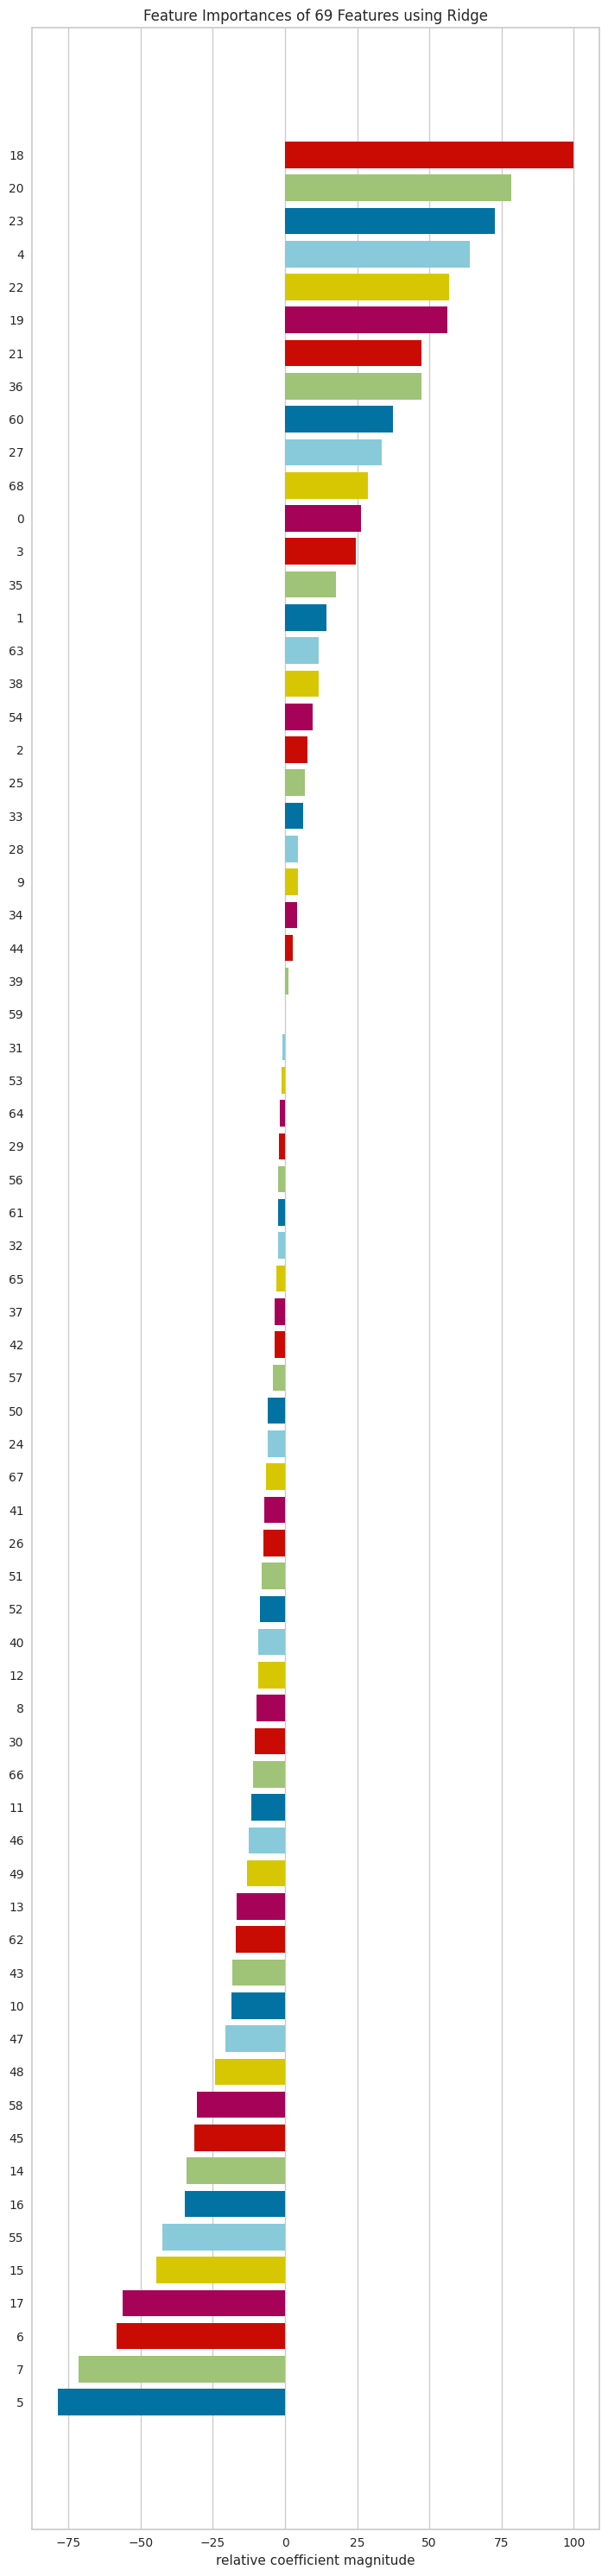

In [186]:
from yellowbrick.model_selection import FeatureImportances
from yellowbrick.features import RadViz

model = Ridge(alpha=0.01)

viz = FeatureImportances(model, labels=pd.DataFrame(X_train).columns)
visualizer = RadViz(size=(720, 3000))
viz.fit(X_train_scaled, y_train)
viz.show();

# We can rank the features according to their importance or make feature
# selection via the FeatureImportances function of the yellowbrick library. We pass the model into the FeatureImportances
# function with the alpha=0.01 hyperparameter that gives the best score for the ridge model. We also give the column names of df as labels.

# After our model completes training on the train data, we obtain our visual with the viz.show() command.
# Since our model is a ridge model, we can only group the features as important and unimportant here. We definitely cannot
# make feature selection.

# The visualizer = RadViz(size=(720, 3000)) command is used only to play with the visual size. The changes in the visual can be observed by changing the numbers 720,3000.

 # <font color='#3D8D7A'> <b>Feature importances with Lasso</b><font color='black'>

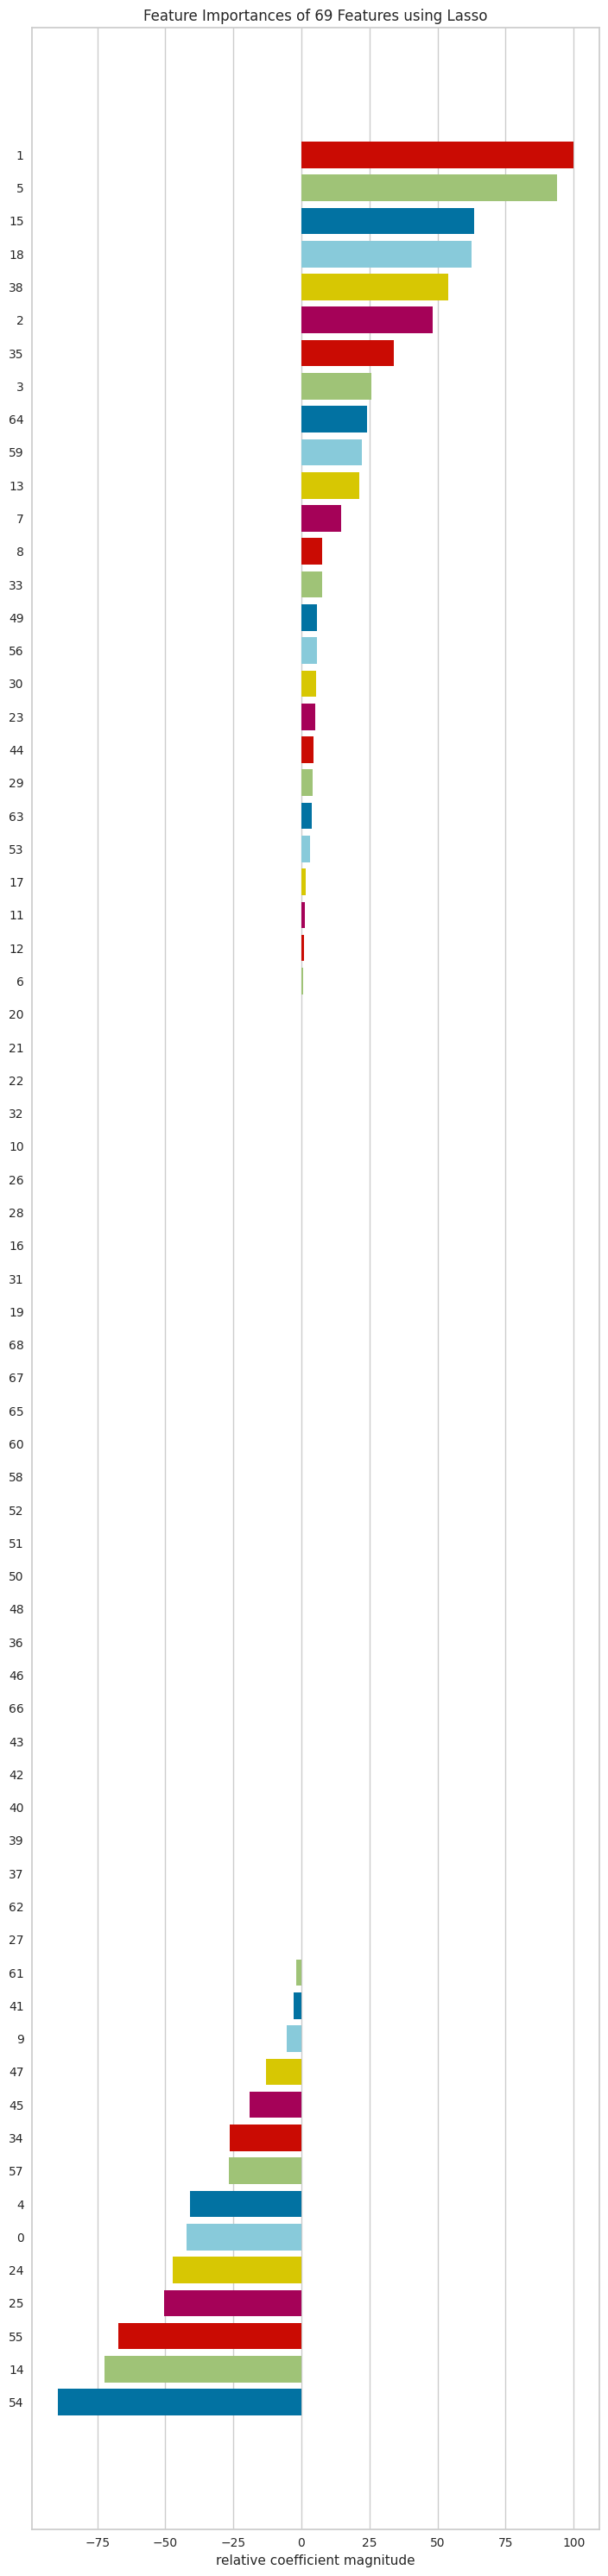

In [187]:
from yellowbrick.model_selection import FeatureImportances
from yellowbrick.features import RadViz

model = Lasso(alpha=0.01)

viz = FeatureImportances(model, labels=pd.DataFrame(X_train).columns)
visualizer = RadViz(size=(720, 3000))
viz.fit(X_train_scaled, y_train)
viz.show();

# We pass the model with the alpha=0.01 hyperparameter that gives the best score for the Lasso model into the FeatureImportances
# function. We also give the column names of df as labels.

# We can perform feature selection via lasso

<b>Follow me </b>[Linkedin](https://www.linkedin.com/in/ejeshbozjanova/) | [Github](github.com/ejeshbozjanova) | [Kaggle](www.kaggle.com/ejeshbozjanova) | [Medium](https://medium.com/@ejeshbozjanova)  |
 <p style="background-color:#3D8D7A;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:10px 20px;"><b>Thank You</b></p>